In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point
import matplotlib.patches as patches
import datetime
import numpy as np

## Map representation

Neighborhood counts:
neighborhood_name
Nueva Bethel        32
Oasis               27
Pantano             27
Ondas del Caribe    27
La Coquera          19
La Quinina          14
San Jacinto          7
8 de Diciembre       6
Name: count, dtype: int64

Non-residential inside neighborhoods: 0


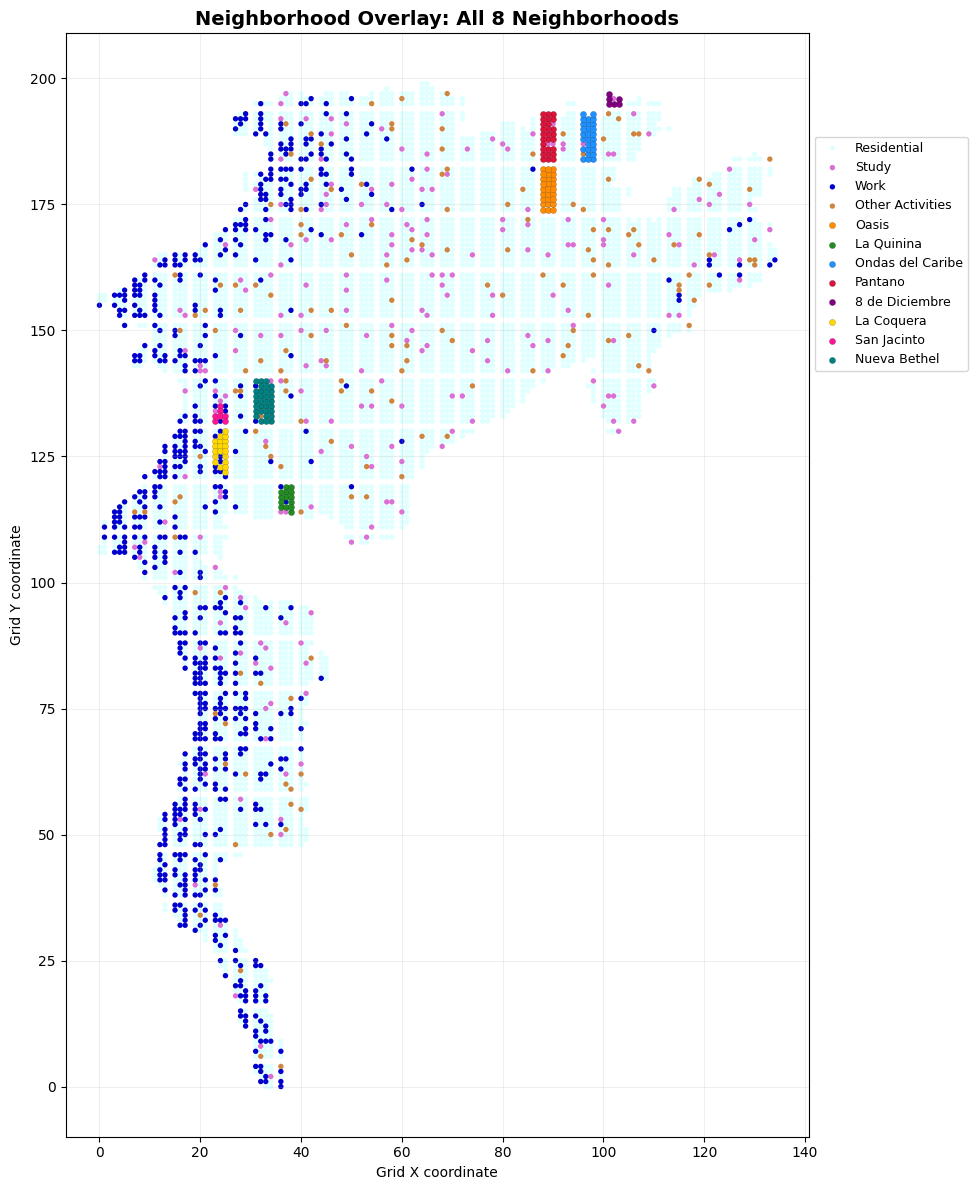


✓ Saved figure: neighborhood_overlay_8neighborhoods.png


In [12]:
# Background: all typed cells
locs = pd.read_csv("locations.csv")  # columns: Category,X,Y

# Neighborhood tags
neigh = pd.read_csv("neighborhood_cells_copy.csv")  # columns: neighborhood_id,neighborhood_name,x,y

# 1) Check counts
print("Neighborhood counts:")
print(neigh["neighborhood_name"].value_counts())

# 2) Verify all neighborhood cells are Residential
merged = neigh.merge(locs, left_on=["x","y"], right_on=["X","Y"], how="left")
bad = merged[merged["Category"] != "Residential"]
print("\nNon-residential inside neighborhoods:", len(bad))
if len(bad) > 0:
    print("WARNING: Found non-residential cells:")
    print(bad[["neighborhood_name", "x", "y", "Category"]])

# 3) Plot overlay with all 8 neighborhoods
color_map = {"Residential":"lightcyan","Study":"orchid","Work":"mediumblue","Other Activities":"peru"}
plt.figure(figsize=(12,12))

# Plot background cells first (lighter colors)
for cat,col in color_map.items():
    sub = locs[locs["Category"] == cat]
    plt.scatter(sub["X"], sub["Y"], s=15, c=col, alpha=1, label=cat, edgecolors='none')

# Define distinct colors for all 8 neighborhoods
neigh_colors = {
    "Oasis": "darkorange", 
    "La Quinina": "forestgreen",
    "Ondas del Caribe": "dodgerblue",
    "Pantano": "crimson",
    "8 de Diciembre": "purple",
    "La Coquera": "gold",
    "San Jacinto": "deeppink",
    "Nueva Bethel": "teal"
}

# Plot neighborhoods with larger markers on top
for name, col in neigh_colors.items():
    sub = neigh[neigh["neighborhood_name"] == name]
    if len(sub) > 0:
        plt.scatter(sub["x"], sub["y"], s=20, c=col, label=f"{name}", 
                   edgecolors='black', linewidths=0.1, alpha=1)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.8), fontsize=9)
plt.gca().set_aspect("equal","box")
plt.title("Neighborhood Overlay: All 8 Neighborhoods", fontsize=14, fontweight='bold')
plt.xlabel("Grid X coordinate")
plt.ylabel("Grid Y coordinate")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("neighborhood_overlay_8neighborhoods.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved figure: neighborhood_overlay_8neighborhoods.png")

## Real Data: Santa Marta Dengue Cases 2023


In [8]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


Dengue (210) dataset shape: (126411, 73)
Severe dengue (220) dataset shape: (1721, 73)

Columns in dengue dataset:
['CONSECUTIVE', 'COD_EVE', 'FEC_NOT', 'SEMANA', 'ANO', 'COD_PRE', 'COD_SUB', 'EDAD', 'UNI_MED', 'nacionalidad', 'nombre_nacionalidad', 'SEXO', 'COD_PAIS_O', 'COD_DPTO_O', 'COD_MUN_O', 'AREA', 'OCUPACION', 'TIP_SS', 'COD_ASE', 'PER_ETN', 'GRU_POB', 'nom_grupo', 'estrato', 'GP_DISCAPA', 'GP_DESPLAZ', 'GP_MIGRANT', 'GP_CARCELA', 'GP_GESTAN', 'sem_ges', 'GP_INDIGEN', 'GP_POBICFB', 'GP_MAD_COM', 'GP_DESMOVI', 'GP_PSIQUIA', 'GP_VIC_VIO', 'GP_OTROS', 'fuente', 'COD_PAIS_R', 'COD_DPTO_R', 'COD_MUN_R', 'COD_DPTO_N', 'COD_MUN_N', 'FEC_CON', 'INI_SIN', 'TIP_CAS', 'PAC_HOS', 'FEC_HOS', 'CON_FIN', 'FEC_DEF', 'AJUSTE', 'FECHA_NTO', 'CER_DEF', 'CBMTE', 'FEC_ARC_XL', 'FEC_AJU', 'FM_FUERZA', 'FM_UNIDAD', 'FM_GRADO', 'confirmados', 'consecutive_origen', 'va_sispro', 'Estado_final_de_caso', 'nom_est_f_caso', 'Nom_upgd', 'Pais_ocurrencia', 'Nombre_evento', 'Departamento_ocurrencia', 'Municipi

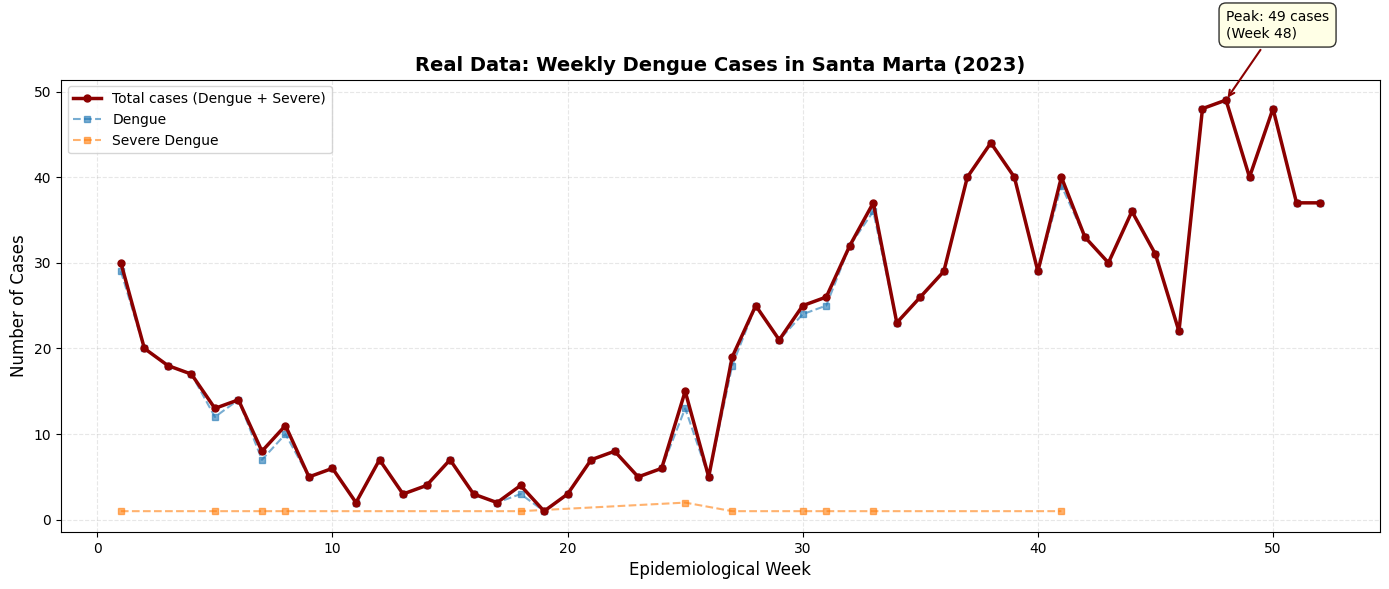


✓ Saved figure: santa_marta_real_weekly_cases.png


In [16]:
# Import real dengue data from Santa Marta (2023)
# Files: 210 = Dengue, 220 = Severe Dengue
import openpyxl

# Read both Excel files
dengue_210 = pd.read_excel("../santa_marta_data/Datos_2023_210.xlsx")
dengue_220 = pd.read_excel("../santa_marta_data/Datos_2023_220.xlsx")

print(f"Dengue (210) dataset shape: {dengue_210.shape}")
print(f"Severe dengue (220) dataset shape: {dengue_220.shape}")

# Check column names to find the correct municipality column
print("\nColumns in dengue dataset:")
print(dengue_210.columns.tolist())

# Filter for Santa Marta (check both possible spellings)
# Try different column name variations
municipality_col = None
for col in dengue_210.columns:
    if 'municipio' in col.lower() and 'ocurr' in col.lower():
        municipality_col = col
        break

if municipality_col:
    print(f"\nFound municipality column: '{municipality_col}'")
    print(f"Unique municipalities (sample): {dengue_210[municipality_col].unique()[:10]}")
    
    # Filter for Santa Marta (try both spellings)
    dengue_210_sm = dengue_210[
        (dengue_210[municipality_col].str.upper().str.contains('SANTA MARTA', na=False)) |
        (dengue_210[municipality_col].str.upper().str.contains('SANTA MARTHA', na=False))
    ].copy()
    
    dengue_220_sm = dengue_220[
        (dengue_220[municipality_col].str.upper().str.contains('SANTA MARTA', na=False)) |
        (dengue_220[municipality_col].str.upper().str.contains('SANTA MARTHA', na=False))
    ].copy()
    
    print(f"\nFiltered cases for Santa Marta:")
    print(f"  Dengue cases: {len(dengue_210_sm)}")
    print(f"  Severe dengue cases: {len(dengue_220_sm)}")
    
    # Add type label
    dengue_210_sm['type'] = 'Dengue'
    dengue_220_sm['type'] = 'Severe Dengue'
    
    # Combine both datasets
    real_data = pd.concat([dengue_210_sm, dengue_220_sm], ignore_index=True)
    
    # Find the week column (SEMANA)
    week_col = None
    for col in real_data.columns:
        if 'semana' in col.lower():
            week_col = col
            break
    
    if week_col:
        print(f"\nFound week column: '{week_col}'")
        
        # Group by week and count cases
        weekly_real = real_data.groupby(week_col).size().reset_index(name='cases')
        weekly_real.rename(columns={week_col: 'week'}, inplace=True)
        
        # Also get breakdown by type
        weekly_by_type = real_data.groupby([week_col, 'type']).size().reset_index(name='cases')
        weekly_by_type.rename(columns={week_col: 'week'}, inplace=True)
        
        print(f"\nWeek range: {weekly_real['week'].min()} to {weekly_real['week'].max()}")
        print(f"Total cases: {weekly_real['cases'].sum()}")
        print(f"Mean weekly cases: {weekly_real['cases'].mean():.1f}")
        print(f"Max weekly cases: {weekly_real['cases'].max()}")
        
        # Plot weekly cases
        plt.figure(figsize=(14, 6))
        
        # Plot total cases
        plt.plot(weekly_real['week'], weekly_real['cases'], 
                linewidth=2.5, color='darkred', marker='o', markersize=5, 
                label='Total cases (Dengue + Severe)', zorder=3)
        
        # Plot breakdown by type
        for dtype in ['Dengue', 'Severe Dengue']:
            subset = weekly_by_type[weekly_by_type['type'] == dtype]
            color = 'orange' if dtype == 'Dengue' else 'crimson'
            plt.plot(subset['week'], subset['cases'], 
                    linewidth=1.5, alpha=0.6, marker='s', markersize=4,
                    label=dtype, linestyle='--')
        
        # Annotate peak
        peak_idx = weekly_real['cases'].idxmax()
        peak_week = weekly_real.loc[peak_idx, 'week']
        peak_cases = weekly_real.loc[peak_idx, 'cases']
        
        plt.annotate(f'Peak: {int(peak_cases)} cases\n(Week {int(peak_week)})',
                    xy=(peak_week, peak_cases),
                    xytext=(peak_week, peak_cases * 1.15),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='darkred'),
                    fontsize=10, 
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))
        
        plt.title('Real Data: Weekly Dengue Cases in Santa Marta (2023)', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Epidemiological Week', fontsize=12)
        plt.ylabel('Number of Cases', fontsize=12)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.legend(fontsize=10, loc='best')
        plt.tight_layout()
        plt.savefig('santa_marta_real_weekly_cases.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Saved figure: santa_marta_real_weekly_cases.png")
        
    else:
        print("Warning: Could not find week column (SEMANA)")
else:
    print("Warning: Could not find municipality column")


In [ ]:
# Adjust for underreporting: Studies suggest 80-90% of dengue cases go unreported
# This means only 10-20% of actual cases are reported

# Load 2024 data as well
print("Loading 2024 data...")
dengue_210_2024 = pd.read_excel("../santa_marta_data/Datos_2024_210.xlsx")
dengue_220_2024 = pd.read_excel("../santa_marta_data/Datos_2024_220.xlsx")

print(f"2024 Dengue (210) dataset shape: {dengue_210_2024.shape}")
print(f"2024 Severe dengue (220) dataset shape: {dengue_220_2024.shape}")

# Filter 2024 data for Santa Marta
dengue_210_sm_2024 = dengue_210_2024[
    (dengue_210_2024[municipality_col].str.upper().str.contains('SANTA MARTA', na=False)) |
    (dengue_210_2024[municipality_col].str.upper().str.contains('SANTA MARTHA', na=False))
].copy()

dengue_220_sm_2024 = dengue_220_2024[
    (dengue_220_2024[municipality_col].str.upper().str.contains('SANTA MARTA', na=False)) |
    (dengue_220_2024[municipality_col].str.upper().str.contains('SANTA MARTHA', na=False))
].copy()

print(f"2024 Filtered cases for Santa Marta:")
print(f"  Dengue cases: {len(dengue_210_sm_2024)}")
print(f"  Severe dengue cases: {len(dengue_220_sm_2024)}")

# Add type label for 2024 data
dengue_210_sm_2024['type'] = 'Dengue'
dengue_220_sm_2024['type'] = 'Severe Dengue'

# Combine 2024 datasets
real_data_2024 = pd.concat([dengue_210_sm_2024, dengue_220_sm_2024], ignore_index=True)

# Group 2024 by week
weekly_real_2024 = real_data_2024.groupby(week_col).size().reset_index(name='cases')
weekly_real_2024.rename(columns={week_col: 'week'}, inplace=True)

# Combine 2023 and 2024 data with year labels
weekly_real['year'] = 2023
weekly_real_2024['year'] = 2024

# For continuous plotting, adjust 2024 weeks to continue after 2023
# 2023 has 52 weeks, so 2024 week 1 becomes week 53, etc.
weekly_real_2024['week_continuous'] = weekly_real_2024['week'] + 52

# Create combined dataset
combined_data = pd.concat([
    weekly_real[['week', 'cases', 'year']].assign(week_continuous=weekly_real['week']),
    weekly_real_2024[['week', 'cases', 'year', 'week_continuous']]
], ignore_index=True)

print(f"\nCombined data summary:")
print(f"2023: {len(weekly_real)} weeks, {weekly_real['cases'].sum()} cases")
print(f"2024: {len(weekly_real_2024)} weeks, {weekly_real_2024['cases'].sum()} cases")
print(f"Total: {combined_data['cases'].sum()} cases")

# Apply 87% underreporting correction to combined data
underreport_factor = 7.7  # 87% underreporting
combined_data['adjusted_cases'] = combined_data['cases'] * underreport_factor

print("\nData loaded successfully! Run the next cell for visualization.")


Loading 2024 data...
2024 Dengue (210) dataset shape: (309627, 72)
2024 Severe dengue (220) dataset shape: (3016, 72)
2024 Filtered cases for Santa Marta:
  Dengue cases: 598
  Severe dengue cases: 10

Combined data summary:
2023: 52 weeks, 1091 cases
2024: 52 weeks, 608 cases
Total: 1699 cases

Data loaded successfully! Run the next cell for visualization.


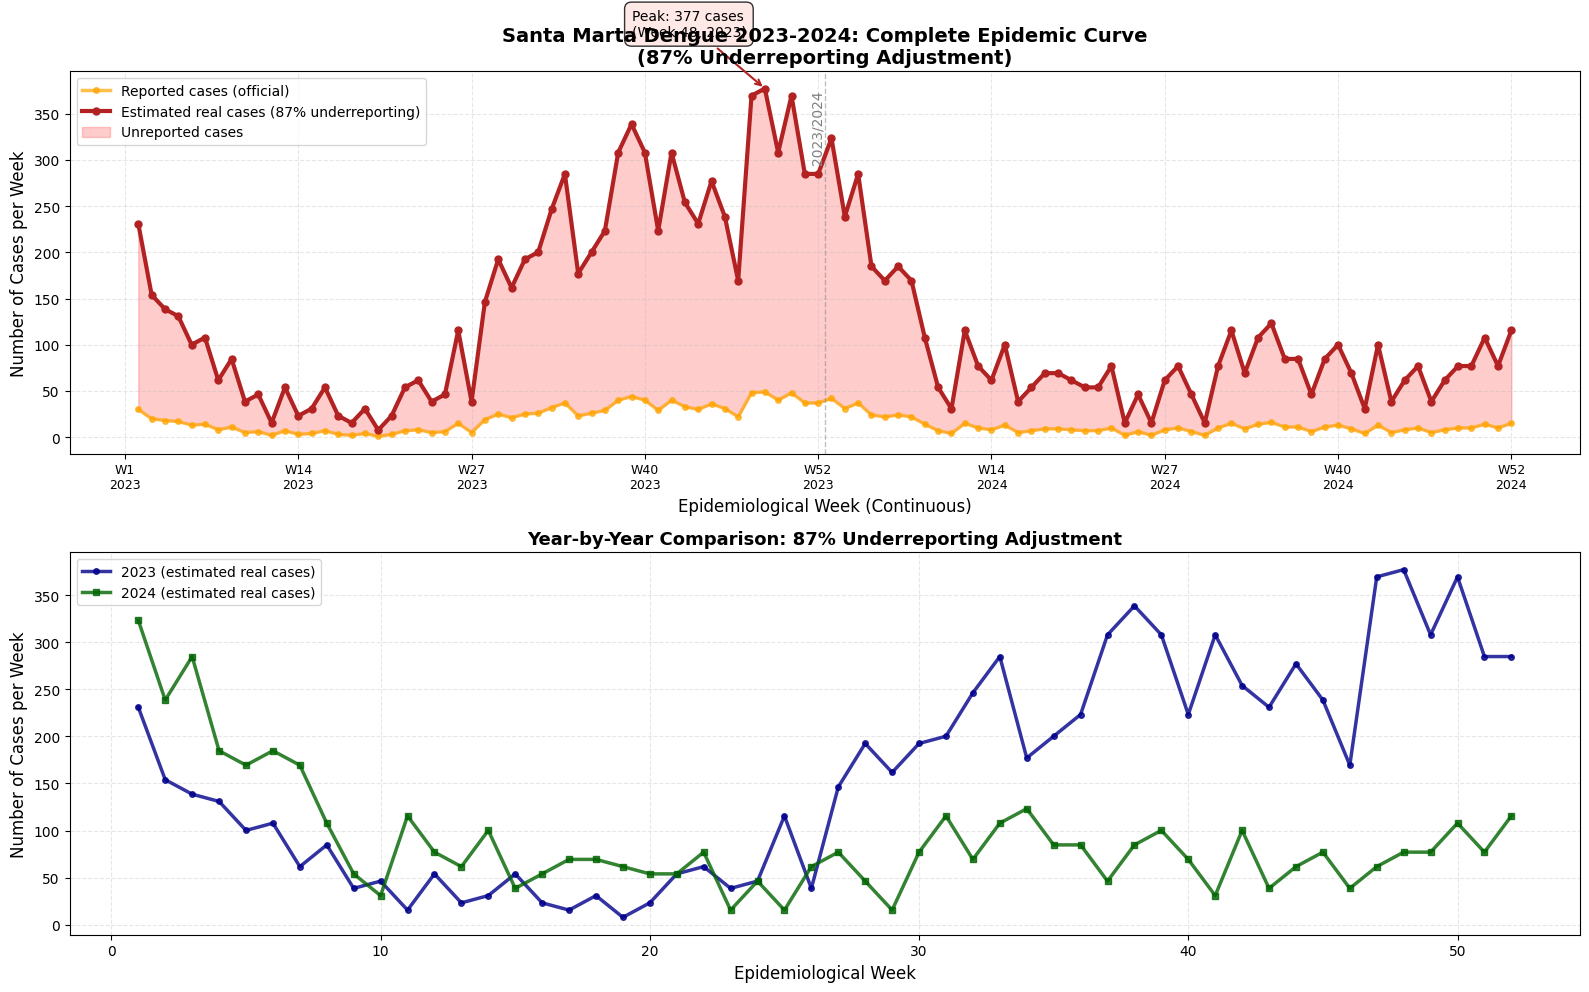

2023-2024 COMBINED ANALYSIS (87% Underreporting)

2023:
  Reported cases: 1091
  Estimated real cases: 8,400
  Peak week: 48 (377 cases)

2024:
  Reported cases: 608
  Estimated real cases: 4,681
  Peak week: 1 (323 cases)

TOTAL (2023-2024):
  Reported cases: 1699
  Estimated real cases: 13,082
  Overall peak: Week 48 (2023) with 377 cases


✓ Saved figure: santa_marta_2023_2024_underreporting.png
✓ Saved data: santa_marta_2023_2024_adjusted_cases.csv


In [18]:
# Plot combined 2023-2024 data with 87% underreporting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# --- SUBPLOT 1: Reported vs Adjusted (87% underreporting) ---
# Plot reported cases
ax1.plot(combined_data['week_continuous'], combined_data['cases'], 
        linewidth=2.5, color='orange', marker='o', markersize=4, 
        label='Reported cases (official)', alpha=0.7)

# Plot adjusted cases (87% underreporting)
ax1.plot(combined_data['week_continuous'], combined_data['adjusted_cases'], 
        linewidth=3, color='firebrick', marker='o', markersize=5, 
        label='Estimated real cases (87% underreporting)', zorder=3)

# Fill between to show the "hidden" cases
ax1.fill_between(combined_data['week_continuous'], combined_data['cases'], 
                combined_data['adjusted_cases'], 
                alpha=0.2, color='red', label='Unreported cases')

# Add year divider line at week 52.5
ax1.axvline(x=52.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(52.5, ax1.get_ylim()[1] * 0.95, '2023/2024', rotation=90, 
         verticalalignment='top', horizontalalignment='right', fontsize=10, color='gray')

# Find and annotate peak
peak_idx = combined_data['adjusted_cases'].idxmax()
peak_week = combined_data.loc[peak_idx, 'week_continuous']
peak_cases = combined_data.loc[peak_idx, 'adjusted_cases']
peak_year = combined_data.loc[peak_idx, 'year']

ax1.annotate(f'Peak: {int(peak_cases)} cases\n(Week {int(combined_data.loc[peak_idx, "week"])}, {int(peak_year)})',
            xy=(peak_week, peak_cases),
            xytext=(peak_week - 10, peak_cases * 1.15),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='firebrick'),
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='mistyrose', alpha=0.8))

ax1.set_title('Santa Marta Dengue 2023-2024: Complete Epidemic Curve\n(87% Underreporting Adjustment)', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Epidemiological Week (Continuous)', fontsize=12)
ax1.set_ylabel('Number of Cases per Week', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10, loc='upper left')

# Add year labels on x-axis
week_ticks = list(range(0, int(combined_data['week_continuous'].max()) + 1, 13))
ax1.set_xticks(week_ticks)
ax1.set_xticklabels([f'W{i%52+1 if i%52 > 0 else 52}\n{2023 + (i-1)//52}' if i > 0 else 'W1\n2023' for i in week_ticks], fontsize=9)

# --- SUBPLOT 2: Year-by-year comparison ---
# Separate data by year
data_2023 = combined_data[combined_data['year'] == 2023]
data_2024 = combined_data[combined_data['year'] == 2024]

# Plot 2023 data
ax2.plot(data_2023['week'], data_2023['adjusted_cases'], 
        linewidth=2.5, color='darkblue', marker='o', markersize=4, 
        label='2023 (estimated real cases)', alpha=0.8)

# Plot 2024 data
ax2.plot(data_2024['week'], data_2024['adjusted_cases'], 
        linewidth=2.5, color='darkgreen', marker='s', markersize=4, 
        label='2024 (estimated real cases)', alpha=0.8)

ax2.set_title('Year-by-Year Comparison: 87% Underreporting Adjustment', 
             fontsize=13, fontweight='bold')
ax2.set_xlabel('Epidemiological Week', fontsize=12)
ax2.set_ylabel('Number of Cases per Week', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('santa_marta_2023_2024_underreporting.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=" * 80)
print("2023-2024 COMBINED ANALYSIS (87% Underreporting)")
print("=" * 80)

# 2023 summary
data_2023 = combined_data[combined_data['year'] == 2023]
print(f"\n2023:")
print(f"  Reported cases: {int(data_2023['cases'].sum())}")
print(f"  Estimated real cases: {int(data_2023['adjusted_cases'].sum()):,}")
print(f"  Peak week: {int(data_2023.loc[data_2023['adjusted_cases'].idxmax(), 'week'])} "
      f"({int(data_2023['adjusted_cases'].max())} cases)")

# 2024 summary  
data_2024 = combined_data[combined_data['year'] == 2024]
print(f"\n2024:")
print(f"  Reported cases: {int(data_2024['cases'].sum())}")
print(f"  Estimated real cases: {int(data_2024['adjusted_cases'].sum()):,}")
if len(data_2024) > 0:
    print(f"  Peak week: {int(data_2024.loc[data_2024['adjusted_cases'].idxmax(), 'week'])} "
          f"({int(data_2024['adjusted_cases'].max())} cases)")

# Combined summary
print(f"\nTOTAL (2023-2024):")
print(f"  Reported cases: {int(combined_data['cases'].sum())}")
print(f"  Estimated real cases: {int(combined_data['adjusted_cases'].sum()):,}")
print(f"  Overall peak: Week {int(combined_data.loc[peak_idx, 'week'])} ({int(peak_year)}) "
      f"with {int(peak_cases)} cases")

print("\n" + "=" * 80)
print("\n✓ Saved figure: santa_marta_2023_2024_underreporting.png")

# Save adjusted cases to CSV
combined_data_to_save = combined_data[['week', 'cases', 'adjusted_cases', 'year', 'week_continuous']].copy()
combined_data_to_save.to_csv('santa_marta_2023_2024_adjusted_cases.csv', index=False)
print("✓ Saved data: santa_marta_2023_2024_adjusted_cases.csv")


In [23]:
# TIME-ALIGNED COMPARISON: Real data from week 21, 2023 to week 20, 2024 (1 year period)
# This matches your simulation time period

# Check if combined_data exists and has data
if 'combined_data' not in locals() or combined_data.empty:
    print("Error: combined_data not found or empty. Please run the previous cell first.")
else:
    print(f"Combined data shape: {combined_data.shape}")
    print(f"Available years: {sorted(combined_data['year'].unique())}")
    print(f"Available weeks: {sorted(combined_data['week'].unique())}")

# Filter real data to match simulation period: Week 21, 2023 to Week 20, 2024
real_aligned_2023 = combined_data[
    (combined_data['year'] == 2023) & (combined_data['week'] >= 21)
].copy()

real_aligned_2024 = combined_data[
    (combined_data['year'] == 2024) & (combined_data['week'] <= 20)
].copy()

print(f"2023 data (weeks >=21): {len(real_aligned_2023)} rows")
print(f"2024 data (weeks <=20): {len(real_aligned_2024)} rows")

# Combine the aligned periods
if len(real_aligned_2023) > 0 and len(real_aligned_2024) > 0:
    real_aligned = pd.concat([real_aligned_2023, real_aligned_2024], ignore_index=True)
elif len(real_aligned_2023) > 0:
    real_aligned = real_aligned_2023.copy()
    print("Warning: Only 2023 data available")
elif len(real_aligned_2024) > 0:
    real_aligned = real_aligned_2024.copy()
    print("Warning: Only 2024 data available")
else:
    print("Error: No data found for the specified time period")
    real_aligned = pd.DataFrame()

# Only proceed if we have data
if not real_aligned.empty:
    # Create continuous week numbering for aligned period (Week 21-52 of 2023, then Week 1-20 of 2024)
    real_aligned['aligned_week'] = range(1, len(real_aligned) + 1)

    print(f"Time-aligned comparison period:")
    print(f"  Real data: Week 21, 2023 to Week 20, 2024 ({len(real_aligned)} weeks)")
    print(f"  Simulation: {len(weekly_cases)} weeks")
    print(f"  Real cases in period: {int(real_aligned['cases'].sum())}")
    print(f"  Real adjusted cases: {int(real_aligned['adjusted_cases'].sum()):,}")
else:
    print("Cannot proceed with comparison - no aligned data available")



# --- TOP RIGHT: Boxplot comparison ---
real_aligned_data = real_aligned['adjusted_cases'].dropna()
sim_data = weekly_cases['new_cases_weekly'].dropna()


# --- BOTTOM RIGHT: Cumulative cases comparison ---
real_cumulative = real_aligned['adjusted_cases'].cumsum()
sim_cumulative = weekly_cases['new_cases_weekly'].cumsum()


plt.suptitle('Time-Aligned Comparison: Real vs Simulated Data\n(Week 21, 2023 to Week 20, 2024)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('time_aligned_comparison_real_vs_simulated.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed comparison
print("\n" + "=" * 80)
print("TIME-ALIGNED COMPARISON: REAL vs SIMULATED")
print("=" * 80)

print(f"\nREAL DATA (Week 21, 2023 to Week 20, 2024, 87% underreporting adjusted):")
print(f"  Sample size: {len(real_aligned_data)} weeks")
print(f"  Mean: {real_aligned_data.mean():.2f} cases/week")
print(f"  Median: {real_aligned_data.median():.2f} cases/week")
print(f"  Std Dev: {real_aligned_data.std():.2f}")
print(f"  Total cases: {int(real_aligned_data.sum()):,}")
print(f"  Peak week: Week {int(real_aligned.loc[real_aligned['adjusted_cases'].idxmax(), 'week'])} "
      f"({int(real_aligned['adjusted_cases'].max())} cases)")

print(f"\nSIMULATED DATA (Same time period):")
print(f"  Sample size: {len(sim_data)} weeks")
print(f"  Mean: {sim_data.mean():.2f} cases/week")
print(f"  Median: {sim_data.median():.2f} cases/week")
print(f"  Std Dev: {sim_data.std():.2f}")
print(f"  Total cases: {int(sim_data.sum()):,}")
print(f"  Peak week: Week {int(weekly_cases.loc[weekly_cases['new_cases_weekly'].idxmax(), 'week'])} "
      f"({int(weekly_cases['new_cases_weekly'].max())} cases)")

# Calculate relative differences
mean_ratio = real_aligned_data.mean() / sim_data.mean()
total_ratio = real_aligned_data.sum() / sim_data.sum()

print(f"\nCOMPARISON RATIOS:")
print(f"  Mean ratio (Real/Sim): {mean_ratio:.2f}")
print(f"  Total cases ratio (Real/Sim): {total_ratio:.2f}")

if mean_ratio > 1:
    print(f"  → Real data shows {mean_ratio:.1f}× higher mean than simulation")
else:
    print(f"  → Simulation shows {1/mean_ratio:.1f}× higher mean than real data")


# Save aligned data
aligned_comparison = pd.DataFrame({
    'aligned_week': real_aligned['aligned_week'],
    'real_week': real_aligned['week'],
    'real_year': real_aligned['year'],
    'real_cases': real_aligned['cases'],
    'real_adjusted_cases': real_aligned['adjusted_cases'],
    'simulated_cases': sim_data[:len(real_aligned)].values
})
aligned_comparison.to_csv('time_aligned_real_vs_simulated.csv', index=False)
print("✓ Saved data: time_aligned_real_vs_simulated.csv")


Combined data shape: (104, 5)
Available years: [np.int64(2023), np.int64(2024)]
Available weeks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
2023 data (weeks >=21): 32 rows
2024 data (weeks <=20): 20 rows
Time-aligned comparison period:
  Real data: Week 21, 2023 to Week 20, 2024 (52 weeks)
  Simulation: 53 weeks
  Real ca

<Figure size 640x480 with 0 Axes>


TIME-ALIGNED COMPARISON: REAL vs SIMULATED

REAL DATA (Week 21, 2023 to Week 20, 2024, 87% underreporting adjusted):
  Sample size: 52 weeks
  Mean: 182.28 cases/week
  Median: 184.80 cases/week
  Std Dev: 105.01
  Total cases: 9,478
  Peak week: Week 48 (377 cases)

SIMULATED DATA (Same time period):
  Sample size: 53 weeks
  Mean: 203.34 cases/week
  Median: 200.00 cases/week
  Std Dev: 42.40
  Total cases: 10,777
  Peak week: Week 11 (273 cases)

COMPARISON RATIOS:
  Mean ratio (Real/Sim): 0.90
  Total cases ratio (Real/Sim): 0.88
  → Simulation shows 1.1× higher mean than real data
✓ Saved data: time_aligned_real_vs_simulated.csv


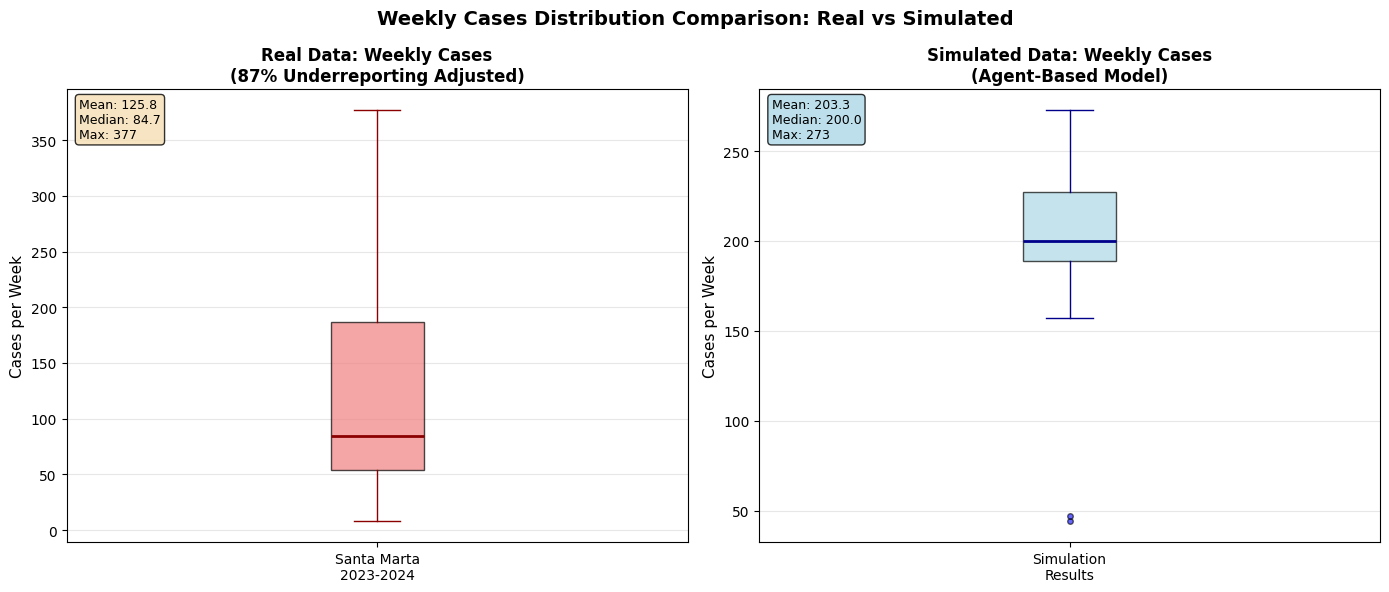

DISTRIBUTION COMPARISON: REAL vs SIMULATED

REAL DATA (Santa Marta 2023-2024, 87% underreporting adjusted):
  Sample size: 104 weeks
  Mean: 125.79 cases/week
  Median: 84.70 cases/week
  Std Dev: 97.90
  Min: 8 cases
  Max: 377 cases
  Q1: 53.90 cases
  Q3: 186.73 cases

SIMULATED DATA (Agent-based model):
  Sample size: 53 weeks
  Mean: 203.34 cases/week
  Median: 200.00 cases/week
  Std Dev: 42.40
  Min: 44 cases
  Max: 273 cases
  Q1: 189.00 cases
  Q3: 227.00 cases

COMPARISON RATIOS:
  Mean ratio (Real/Sim): 0.62
  Median ratio (Real/Sim): 0.42
  → Simulation shows 1.6× higher mean than real data

✓ Saved figure: boxplot_comparison_real_vs_simulated.png


In [24]:
# Side-by-side boxplot comparison: Real vs Simulated weekly cases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: Real Data (Adjusted Cases) ---
real_data = combined_data['adjusted_cases'].dropna()
ax1.boxplot(real_data, patch_artist=True, 
           boxprops=dict(facecolor='lightcoral', alpha=0.7),
           medianprops=dict(color='darkred', linewidth=2),
           whiskerprops=dict(color='darkred'),
           capprops=dict(color='darkred'),
           flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))

ax1.set_title('Real Data: Weekly Cases\n(87% Underreporting Adjusted)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cases per Week', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels(['Santa Marta\n2023-2024'])

# Add statistics text
real_stats = f'Mean: {real_data.mean():.1f}\nMedian: {real_data.median():.1f}\nMax: {real_data.max():.0f}'
ax1.text(0.02, 0.98, real_stats, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- RIGHT: Simulated Data ---
sim_data = weekly_cases['new_cases_weekly'].dropna()
ax2.boxplot(sim_data, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7),
           medianprops=dict(color='darkblue', linewidth=2),
           whiskerprops=dict(color='darkblue'),
           capprops=dict(color='darkblue'),
           flierprops=dict(marker='o', markerfacecolor='blue', markersize=4, alpha=0.6))

ax2.set_title('Simulated Data: Weekly Cases\n(Agent-Based Model)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cases per Week', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['Simulation\nResults'])

# Add statistics text
sim_stats = f'Mean: {sim_data.mean():.1f}\nMedian: {sim_data.median():.1f}\nMax: {sim_data.max():.0f}'
ax2.text(0.02, 0.98, sim_stats, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.suptitle('Weekly Cases Distribution Comparison: Real vs Simulated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_comparison_real_vs_simulated.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed comparison
print("=" * 70)
print("DISTRIBUTION COMPARISON: REAL vs SIMULATED")
print("=" * 70)

print(f"\nREAL DATA (Santa Marta 2023-2024, 87% underreporting adjusted):")
print(f"  Sample size: {len(real_data)} weeks")
print(f"  Mean: {real_data.mean():.2f} cases/week")
print(f"  Median: {real_data.median():.2f} cases/week")
print(f"  Std Dev: {real_data.std():.2f}")
print(f"  Min: {real_data.min():.0f} cases")
print(f"  Max: {real_data.max():.0f} cases")
print(f"  Q1: {real_data.quantile(0.25):.2f} cases")
print(f"  Q3: {real_data.quantile(0.75):.2f} cases")

print(f"\nSIMULATED DATA (Agent-based model):")
print(f"  Sample size: {len(sim_data)} weeks")
print(f"  Mean: {sim_data.mean():.2f} cases/week")
print(f"  Median: {sim_data.median():.2f} cases/week")
print(f"  Std Dev: {sim_data.std():.2f}")
print(f"  Min: {sim_data.min():.0f} cases")
print(f"  Max: {sim_data.max():.0f} cases")
print(f"  Q1: {sim_data.quantile(0.25):.2f} cases")
print(f"  Q3: {sim_data.quantile(0.75):.2f} cases")

# Calculate relative differences
mean_ratio = real_data.mean() / sim_data.mean()
median_ratio = real_data.median() / sim_data.median()

print(f"\nCOMPARISON RATIOS:")
print(f"  Mean ratio (Real/Sim): {mean_ratio:.2f}")
print(f"  Median ratio (Real/Sim): {median_ratio:.2f}")

if mean_ratio > 1:
    print(f"  → Real data shows {mean_ratio:.1f}× higher mean than simulation")
else:
    print(f"  → Simulation shows {1/mean_ratio:.1f}× higher mean than real data")

print("\n" + "=" * 70)
print("✓ Saved figure: boxplot_comparison_real_vs_simulated.png")


INCIDENCE RATE PER 100,000 POPULATION - SANTA MARTA
Population (2023): 555,030

2023:
  Total reported cases: 1,091
  Total adjusted cases: 8,400
  Annual incidence (reported): 196.57 per 100k
  Annual incidence (adjusted): 1513.56 per 100k
  Mean weekly incidence (reported): 3.78 per 100k
  Mean weekly incidence (adjusted): 29.11 per 100k
  Peak weekly incidence (adjusted): 67.98 per 100k (Week 48)

2024:
  Total reported cases: 608
  Total adjusted cases: 4,681
  Annual incidence (reported): 109.54 per 100k
  Annual incidence (adjusted): 843.49 per 100k
  Mean weekly incidence (reported): 2.11 per 100k
  Mean weekly incidence (adjusted): 16.22 per 100k
  Peak weekly incidence (adjusted): 58.27 per 100k (Week 1)


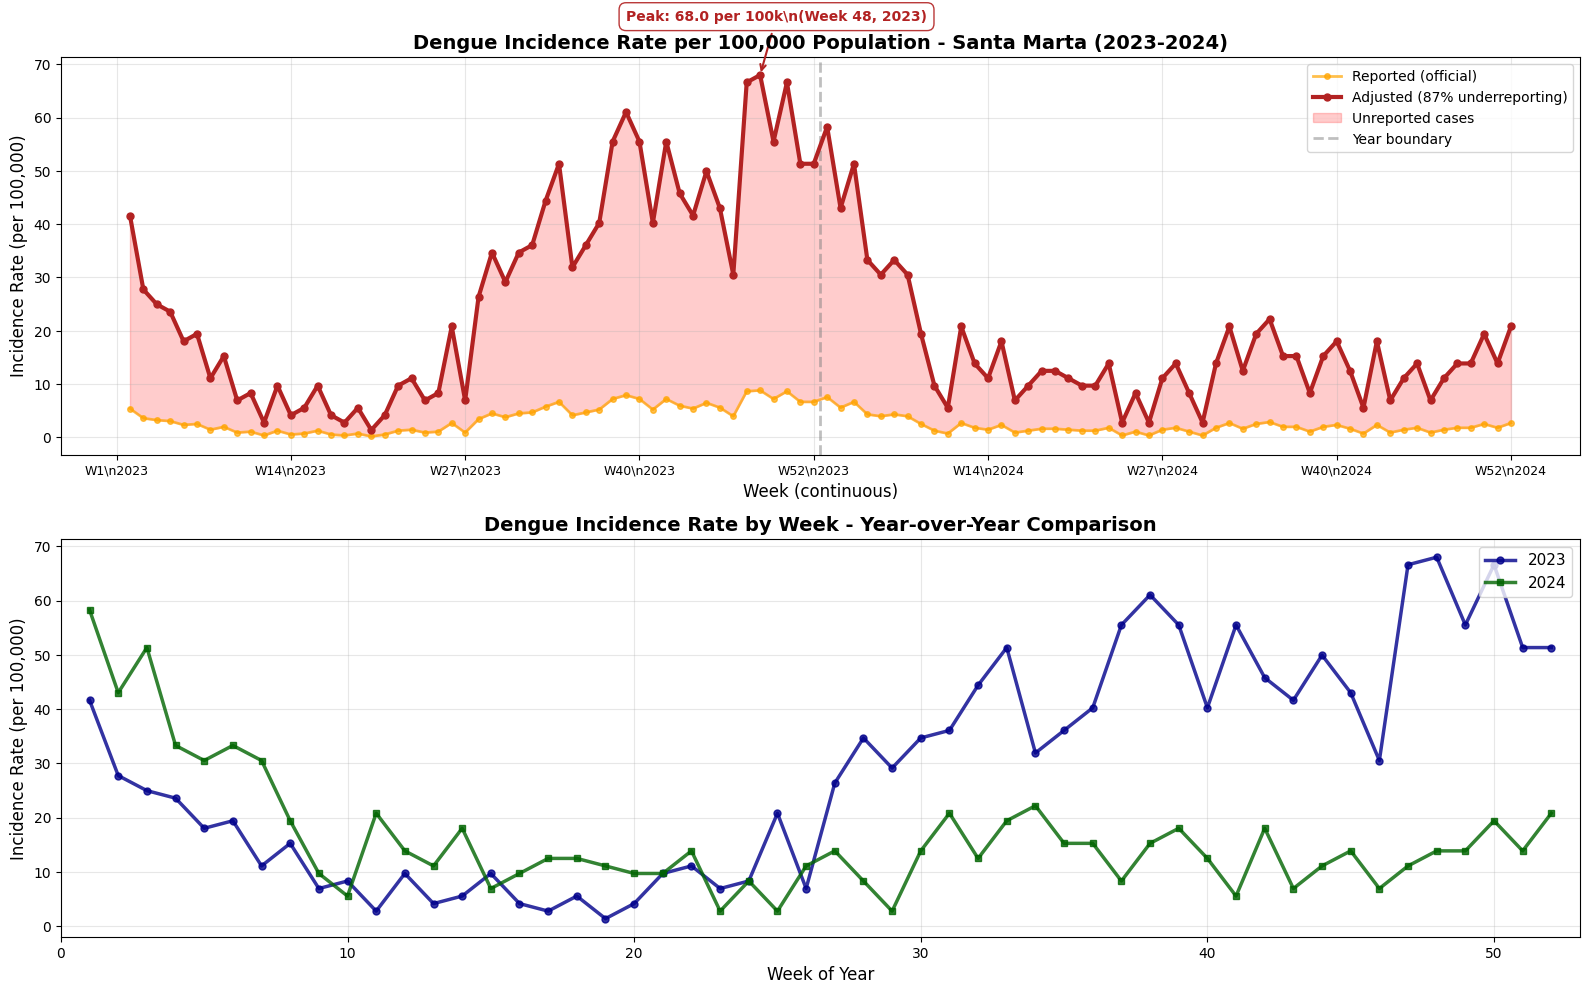

\n================================================================================
✓ Saved figure: incidence_rate.png


In [25]:
# Calculate Incidence Rate per 100,000 population for Santa Marta
# Population of Santa Marta in 2023: 555,030

SANTA_MARTA_POP_2023 = 555030

# Calculate incidence rate per 100k for both reported and adjusted cases
combined_data['incidence_rate_reported'] = (combined_data['cases'] / SANTA_MARTA_POP_2023) * 100000
combined_data['incidence_rate_adjusted'] = (combined_data['adjusted_cases'] / SANTA_MARTA_POP_2023) * 100000

# Summary statistics
print("="*80)
print("INCIDENCE RATE PER 100,000 POPULATION - SANTA MARTA")
print(f"Population (2023): {SANTA_MARTA_POP_2023:,}")
print("="*80)

# 2023 data
data_2023 = combined_data[combined_data['year'] == 2023]
print(f"\n2023:")
print(f"  Total reported cases: {int(data_2023['cases'].sum()):,}")
print(f"  Total adjusted cases: {int(data_2023['adjusted_cases'].sum()):,}")
print(f"  Annual incidence (reported): {(data_2023['cases'].sum() / SANTA_MARTA_POP_2023) * 100000:.2f} per 100k")
print(f"  Annual incidence (adjusted): {(data_2023['adjusted_cases'].sum() / SANTA_MARTA_POP_2023) * 100000:.2f} per 100k")
print(f"  Mean weekly incidence (reported): {data_2023['incidence_rate_reported'].mean():.2f} per 100k")
print(f"  Mean weekly incidence (adjusted): {data_2023['incidence_rate_adjusted'].mean():.2f} per 100k")
print(f"  Peak weekly incidence (adjusted): {data_2023['incidence_rate_adjusted'].max():.2f} per 100k " + 
      f"(Week {int(data_2023.loc[data_2023['incidence_rate_adjusted'].idxmax(), 'week'])})")

# 2024 data
data_2024 = combined_data[combined_data['year'] == 2024]
if len(data_2024) > 0:
    print(f"\n2024:")
    print(f"  Total reported cases: {int(data_2024['cases'].sum()):,}")
    print(f"  Total adjusted cases: {int(data_2024['adjusted_cases'].sum()):,}")
    print(f"  Annual incidence (reported): {(data_2024['cases'].sum() / SANTA_MARTA_POP_2023) * 100000:.2f} per 100k")
    print(f"  Annual incidence (adjusted): {(data_2024['adjusted_cases'].sum() / SANTA_MARTA_POP_2023) * 100000:.2f} per 100k")
    print(f"  Mean weekly incidence (reported): {data_2024['incidence_rate_reported'].mean():.2f} per 100k")
    print(f"  Mean weekly incidence (adjusted): {data_2024['incidence_rate_adjusted'].mean():.2f} per 100k")
    print(f"  Peak weekly incidence (adjusted): {data_2024['incidence_rate_adjusted'].max():.2f} per 100k " +
          f"(Week {int(data_2024.loc[data_2024['incidence_rate_adjusted'].idxmax(), 'week'])})")

# Plot incidence rates
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Top panel: Continuous time series (2023-2024)
ax1.plot(combined_data['week_continuous'], combined_data['incidence_rate_reported'], 
        linewidth=2, color='orange', marker='o', markersize=4, 
        label='Reported (official)', alpha=0.7)

ax1.plot(combined_data['week_continuous'], combined_data['incidence_rate_adjusted'], 
        linewidth=3, color='firebrick', marker='o', markersize=5, 
        label='Adjusted (87% underreporting)', zorder=3)

# Fill between
ax1.fill_between(combined_data['week_continuous'], 
                combined_data['incidence_rate_reported'], 
                combined_data['incidence_rate_adjusted'], 
                alpha=0.2, color='red', label='Unreported cases')

# Year divider
ax1.axvline(x=52.5, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Year boundary')

# Annotate peak
peak_idx = combined_data['incidence_rate_adjusted'].idxmax()
peak_week_cont = combined_data.loc[peak_idx, 'week_continuous']
peak_rate = combined_data.loc[peak_idx, 'incidence_rate_adjusted']
peak_year = combined_data.loc[peak_idx, 'year']
peak_week_orig = combined_data.loc[peak_idx, 'week']

ax1.annotate(f'Peak: {peak_rate:.1f} per 100k\\n(Week {int(peak_week_orig)}, {int(peak_year)})',
            xy=(peak_week_cont, peak_rate),
            xytext=(peak_week_cont - 10, peak_rate * 1.15),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='firebrick'),
            fontsize=10, fontweight='bold', color='firebrick',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='firebrick', alpha=0.9))

ax1.set_title('Dengue Incidence Rate per 100,000 Population - Santa Marta (2023-2024)', 
             fontsize=14, fontweight='bold')
ax1.set_xlabel('Week (continuous)', fontsize=12)
ax1.set_ylabel('Incidence Rate (per 100,000)', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add year labels
week_ticks = list(range(0, int(combined_data['week_continuous'].max()) + 1, 13))
ax1.set_xticks(week_ticks)
ax1.set_xticklabels([f'W{i%52+1 if i%52 > 0 else 52}\\n{2023 + (i-1)//52}' if i > 0 else 'W1\\n2023' for i in week_ticks], fontsize=9)

# Bottom panel: Year-over-year comparison
ax2.plot(data_2023['week'], data_2023['incidence_rate_adjusted'], 
        linewidth=2.5, color='darkblue', marker='o', markersize=5, 
        label='2023', alpha=0.8)

if len(data_2024) > 0:
    ax2.plot(data_2024['week'], data_2024['incidence_rate_adjusted'], 
            linewidth=2.5, color='darkgreen', marker='s', markersize=5, 
            label='2024', alpha=0.8)

ax2.set_title('Dengue Incidence Rate by Week - Year-over-Year Comparison', 
             fontsize=14, fontweight='bold')
ax2.set_xlabel('Week of Year', fontsize=12)
ax2.set_ylabel('Incidence Rate (per 100,000)', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 53)

plt.tight_layout()
plt.savefig('incidence_rate.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\n" + "="*80)
print("✓ Saved figure: incidence_rate.png")
print("="*80)


In [27]:
combined_data_to_save = combined_data[['week', 'cases', 'adjusted_cases','incidence_rate_adjusted', 'year', 'week_continuous']].copy()
combined_data_to_save.to_csv('santa_marta_2023_2024_adjusted_cases.csv', index=False)
print("✓ Saved data: santa_marta_2023_2024_adjusted_cases.csv")

✓ Saved data: santa_marta_2023_2024_adjusted_cases.csv


Combined data shape: (104, 7)
Available years: [np.int64(2023), np.int64(2024)]
Available weeks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52)]
2023 data (weeks >=21): 32 rows
2024 data (weeks <=20): 20 rows
Time-aligned comparison period:
  Real data: Week 21, 2023 to Week 20, 2024 (52 weeks)
  Simulation: 53 weeks
  Real ca

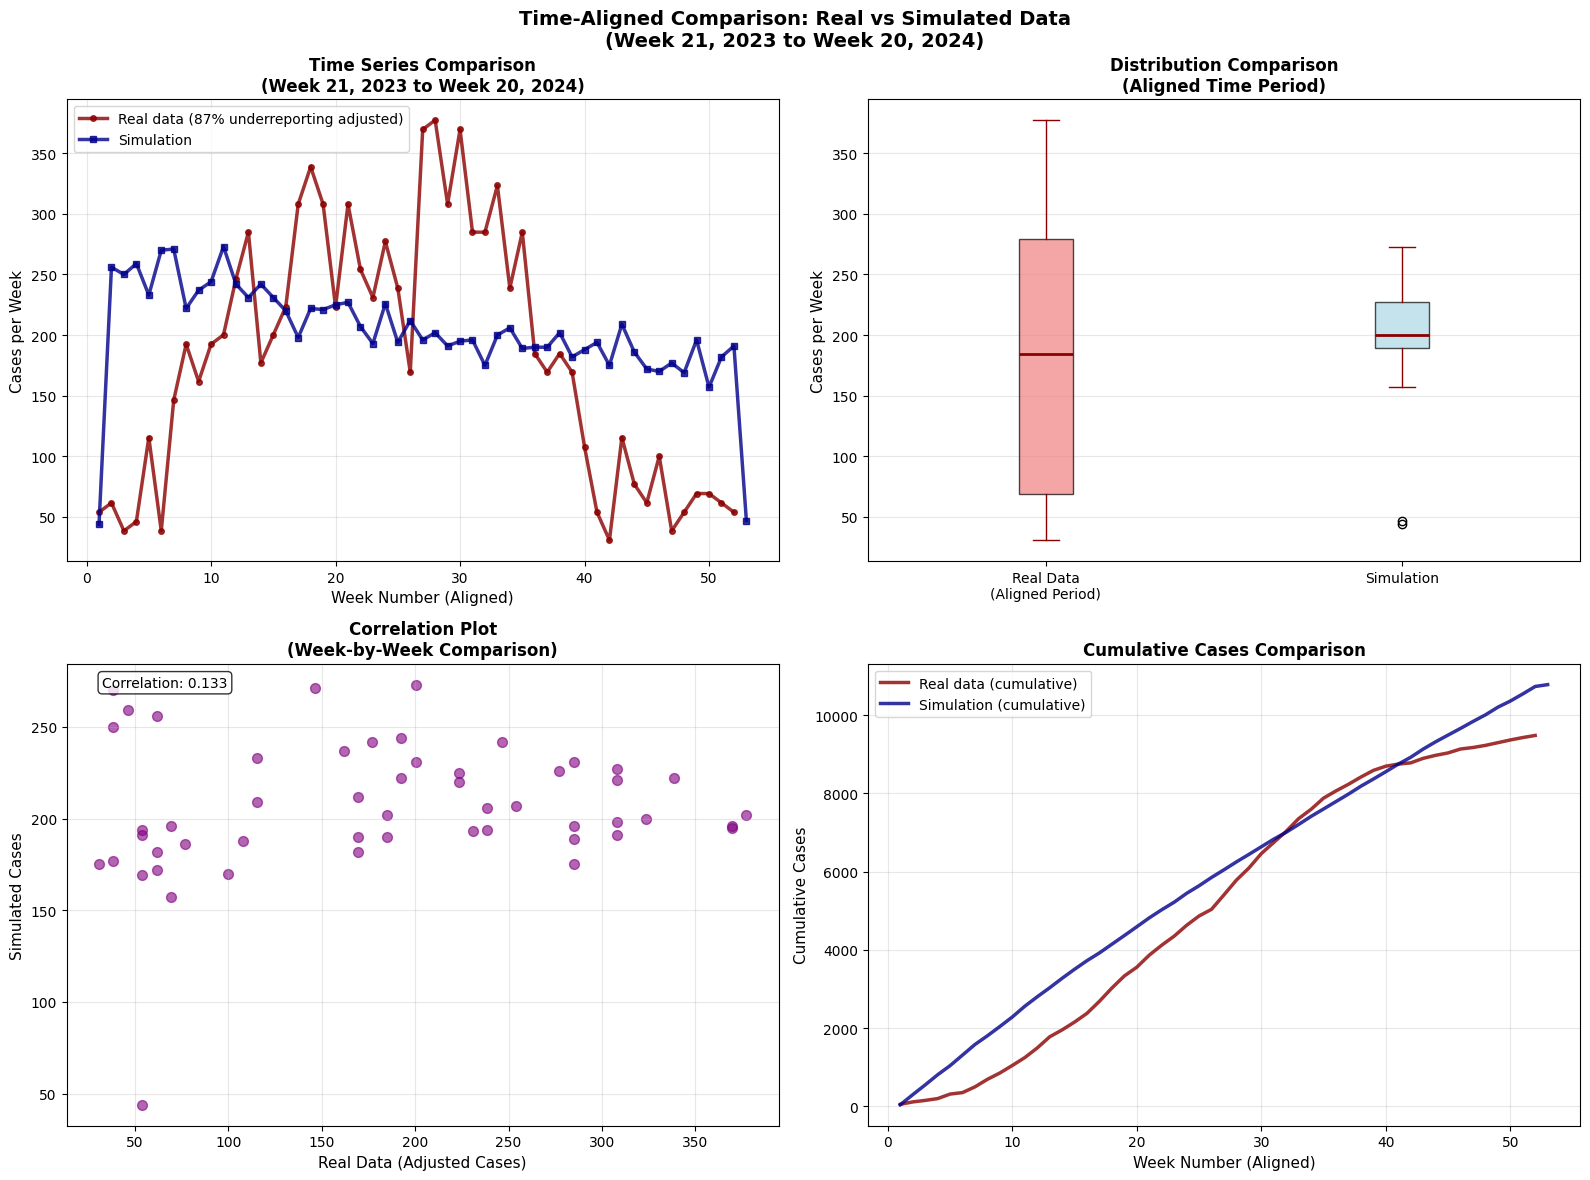


TIME-ALIGNED COMPARISON: REAL vs SIMULATED

REAL DATA (Week 21, 2023 to Week 20, 2024, 87% underreporting adjusted):
  Sample size: 52 weeks
  Mean: 182.28 cases/week
  Median: 184.80 cases/week
  Std Dev: 105.01
  Total cases: 9,478
  Peak week: Week 48 (377 cases)

SIMULATED DATA (Same time period):
  Sample size: 53 weeks
  Mean: 203.34 cases/week
  Median: 200.00 cases/week
  Std Dev: 42.40
  Total cases: 10,777
  Peak week: Week 11 (273 cases)

COMPARISON RATIOS:
  Mean ratio (Real/Sim): 0.90
  Total cases ratio (Real/Sim): 0.88
  → Simulation shows 1.1× higher mean than real data

✓ Saved figure: time_aligned_comparison_real_vs_simulated.png
✓ Saved data: time_aligned_real_vs_simulated.csv


In [29]:
# FIXED VERSION: TIME-ALIGNED COMPARISON with error handling
# Real data from week 21, 2023 to week 20, 2024 (1 year period)

# Check if combined_data exists and has data
if 'combined_data' not in locals() or combined_data.empty:
    print("Error: combined_data not found or empty. Please run the previous cell first.")
else:
    print(f"Combined data shape: {combined_data.shape}")
    print(f"Available years: {sorted(combined_data['year'].unique())}")
    print(f"Available weeks: {sorted(combined_data['week'].unique())}")

# Filter real data to match simulation period: Week 21, 2023 to Week 20, 2024
real_aligned_2023 = combined_data[
    (combined_data['year'] == 2023) & (combined_data['week'] >= 21)
].copy()

real_aligned_2024 = combined_data[
    (combined_data['year'] == 2024) & (combined_data['week'] <= 20)
].copy()

print(f"2023 data (weeks >=21): {len(real_aligned_2023)} rows")
print(f"2024 data (weeks <=20): {len(real_aligned_2024)} rows")

# Combine the aligned periods
if len(real_aligned_2023) > 0 and len(real_aligned_2024) > 0:
    real_aligned = pd.concat([real_aligned_2023, real_aligned_2024], ignore_index=True)
elif len(real_aligned_2023) > 0:
    real_aligned = real_aligned_2023.copy()
    print("Warning: Only 2023 data available")
elif len(real_aligned_2024) > 0:
    real_aligned = real_aligned_2024.copy()
    print("Warning: Only 2024 data available")
else:
    print("Error: No data found for the specified time period")
    real_aligned = pd.DataFrame()

# Only proceed if we have data
if not real_aligned.empty:
    # Create continuous week numbering for aligned period
    real_aligned['aligned_week'] = range(1, len(real_aligned) + 1)

    print(f"Time-aligned comparison period:")
    print(f"  Real data: Week 21, 2023 to Week 20, 2024 ({len(real_aligned)} weeks)")
    print(f"  Simulation: {len(weekly_cases)} weeks")
    print(f"  Real cases in period: {int(real_aligned['cases'].sum())}")
    print(f"  Real adjusted cases: {int(real_aligned['adjusted_cases'].sum()):,}")
    
    # Create time-aligned comparison plots only if we have data
    if 'weekly_cases' in locals() and not weekly_cases.empty:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        # --- TOP LEFT: Time series comparison ---
        ax1.plot(real_aligned['aligned_week'], real_aligned['adjusted_cases'], 
                linewidth=2.5, color='darkred', marker='o', markersize=4, 
                label='Real data (87% underreporting adjusted)', alpha=0.8)

        ax1.plot(weekly_cases['week'], weekly_cases['new_cases_weekly'], 
                linewidth=2.5, color='darkblue', marker='s', markersize=4, 
                label='Simulation', alpha=0.8)

        ax1.set_title('Time Series Comparison\n(Week 21, 2023 to Week 20, 2024)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Week Number (Aligned)', fontsize=11)
        ax1.set_ylabel('Cases per Week', fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=10)

        # --- TOP RIGHT: Boxplot comparison (FIXED) ---
        real_aligned_data = real_aligned['adjusted_cases'].dropna()
        sim_data = weekly_cases['new_cases_weekly'].dropna()

        # Create boxplot with proper error handling
        box_plot = ax2.boxplot([real_aligned_data, sim_data], patch_artist=True, 
                   tick_labels=['Real Data\n(Aligned Period)', 'Simulation'],
                   boxprops=dict(facecolor='lightcoral', alpha=0.7),
                   medianprops=dict(color='darkred', linewidth=2),
                   whiskerprops=dict(color='darkred'),
                   capprops=dict(color='darkred'))

        # Set different colors for simulation box - FIXED VERSION
        boxes = box_plot['boxes']
        if len(boxes) >= 2:
            boxes[1].set_facecolor('lightblue')
            boxes[1].set_alpha(0.7)
        elif len(boxes) == 1:
            print("Warning: Only one box created in boxplot")

        ax2.set_title('Distribution Comparison\n(Aligned Time Period)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cases per Week', fontsize=11)
        ax2.grid(True, alpha=0.3, axis='y')

        # --- BOTTOM LEFT: Scatter plot correlation ---
        ax3.scatter(real_aligned_data, sim_data[:len(real_aligned_data)], 
                   alpha=0.6, s=50, color='purple')
        ax3.set_xlabel('Real Data (Adjusted Cases)', fontsize=11)
        ax3.set_ylabel('Simulated Cases', fontsize=11)
        ax3.set_title('Correlation Plot\n(Week-by-Week Comparison)', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)

        # Add correlation coefficient
        try:
            sim_data_truncated = sim_data[:len(real_aligned_data)]
            if len(real_aligned_data) == len(sim_data_truncated) and len(real_aligned_data) > 1:
                correlation = np.corrcoef(real_aligned_data, sim_data_truncated)[0,1]
                ax3.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                        transform=ax3.transAxes, fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            else:
                ax3.text(0.05, 0.95, 'Correlation: N/A\n(Length mismatch)', 
                        transform=ax3.transAxes, fontsize=10,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        except Exception as e:
            ax3.text(0.05, 0.95, f'Correlation: Error\n{str(e)[:20]}', 
                    transform=ax3.transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # --- BOTTOM RIGHT: Cumulative cases comparison ---
        real_cumulative = real_aligned['adjusted_cases'].cumsum()
        sim_cumulative = weekly_cases['new_cases_weekly'].cumsum()

        ax4.plot(real_aligned['aligned_week'], real_cumulative, 
                linewidth=2.5, color='darkred', label='Real data (cumulative)', alpha=0.8)
        ax4.plot(weekly_cases['week'], sim_cumulative, 
                linewidth=2.5, color='darkblue', label='Simulation (cumulative)', alpha=0.8)

        ax4.set_title('Cumulative Cases Comparison', fontsize=12, fontweight='bold')
        ax4.set_xlabel('Week Number (Aligned)', fontsize=11)
        ax4.set_ylabel('Cumulative Cases', fontsize=11)
        ax4.grid(True, alpha=0.3)
        ax4.legend(fontsize=10)

        plt.suptitle('Time-Aligned Comparison: Real vs Simulated Data\n(Week 21, 2023 to Week 20, 2024)', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('time_aligned_comparison_real_vs_simulated.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Print detailed comparison
        print("\n" + "=" * 80)
        print("TIME-ALIGNED COMPARISON: REAL vs SIMULATED")
        print("=" * 80)

        print(f"\nREAL DATA (Week 21, 2023 to Week 20, 2024, 87% underreporting adjusted):")
        print(f"  Sample size: {len(real_aligned_data)} weeks")
        print(f"  Mean: {real_aligned_data.mean():.2f} cases/week")
        print(f"  Median: {real_aligned_data.median():.2f} cases/week")
        print(f"  Std Dev: {real_aligned_data.std():.2f}")
        print(f"  Total cases: {int(real_aligned_data.sum()):,}")
        print(f"  Peak week: Week {int(real_aligned.loc[real_aligned['adjusted_cases'].idxmax(), 'week'])} "
              f"({int(real_aligned['adjusted_cases'].max())} cases)")

        print(f"\nSIMULATED DATA (Same time period):")
        print(f"  Sample size: {len(sim_data)} weeks")
        print(f"  Mean: {sim_data.mean():.2f} cases/week")
        print(f"  Median: {sim_data.median():.2f} cases/week")
        print(f"  Std Dev: {sim_data.std():.2f}")
        print(f"  Total cases: {int(sim_data.sum()):,}")
        print(f"  Peak week: Week {int(weekly_cases.loc[weekly_cases['new_cases_weekly'].idxmax(), 'week'])} "
              f"({int(weekly_cases['new_cases_weekly'].max())} cases)")

        # Calculate relative differences
        mean_ratio = real_aligned_data.mean() / sim_data.mean()
        total_ratio = real_aligned_data.sum() / sim_data.sum()

        print(f"\nCOMPARISON RATIOS:")
        print(f"  Mean ratio (Real/Sim): {mean_ratio:.2f}")
        print(f"  Total cases ratio (Real/Sim): {total_ratio:.2f}")

        if mean_ratio > 1:
            print(f"  → Real data shows {mean_ratio:.1f}× higher mean than simulation")
        else:
            print(f"  → Simulation shows {1/mean_ratio:.1f}× higher mean than real data")

        print("\n" + "=" * 80)
        print("✓ Saved figure: time_aligned_comparison_real_vs_simulated.png")

        # Save aligned data
        try:
            aligned_comparison = pd.DataFrame({
                'aligned_week': real_aligned['aligned_week'],
                'real_week': real_aligned['week'],
                'real_year': real_aligned['year'],
                'real_cases': real_aligned['cases'],
                'real_adjusted_cases': real_aligned['adjusted_cases'],
                'simulated_cases': sim_data[:len(real_aligned)].values
            })
            aligned_comparison.to_csv('time_aligned_real_vs_simulated.csv', index=False)
            print("✓ Saved data: time_aligned_real_vs_simulated.csv")
        except Exception as e:
            print(f"Error saving data: {e}")
    else:
        print("Skipping plotting - weekly_cases not available")
else:
    print("Cannot complete comparison - insufficient data")


In [35]:
incidence_rates_santa_marta = real_aligned[['week', 'week_continuous','incidence_rate_adjusted']].copy()
incidence_rates_santa_marta.to_csv('incidence_rates_santa_marta.csv', index=False)
incidence_rates_santa_marta


,week,week_continuous,incidence_rate_adjusted
0,21,21,9.711187
1,22,22,11.098499
2,23,23,6.936562
3,24,24,8.323874
4,25,25,20.809686
5,26,26,6.936562
6,27,27,26.358936
7,28,28,34.682810
8,29,29,29.133560
9,30,30,34.682810


In [33]:
real_aligned

,week,cases,year,week_continuous,adjusted_cases,incidence_rate_reported,incidence_rate_adjusted,aligned_week
0,21,7,2023,21,53.9,1.261193,9.711187,1
1,22,8,2023,22,61.6,1.441364,11.098499,2
2,23,5,2023,23,38.5,0.900852,6.936562,3
3,24,6,2023,24,46.2,1.081023,8.323874,4
4,25,15,2023,25,115.5,2.702557,20.809686,5
5,26,5,2023,26,38.5,0.900852,6.936562,6
6,27,19,2023,27,146.3,3.423238,26.358936,7
7,28,25,2023,28,192.5,4.504261,34.682810,8
8,29,21,2023,29,161.7,3.783579,29.133560,9
9,30,25,2023,30,192.5,4.504261,34.682810,10


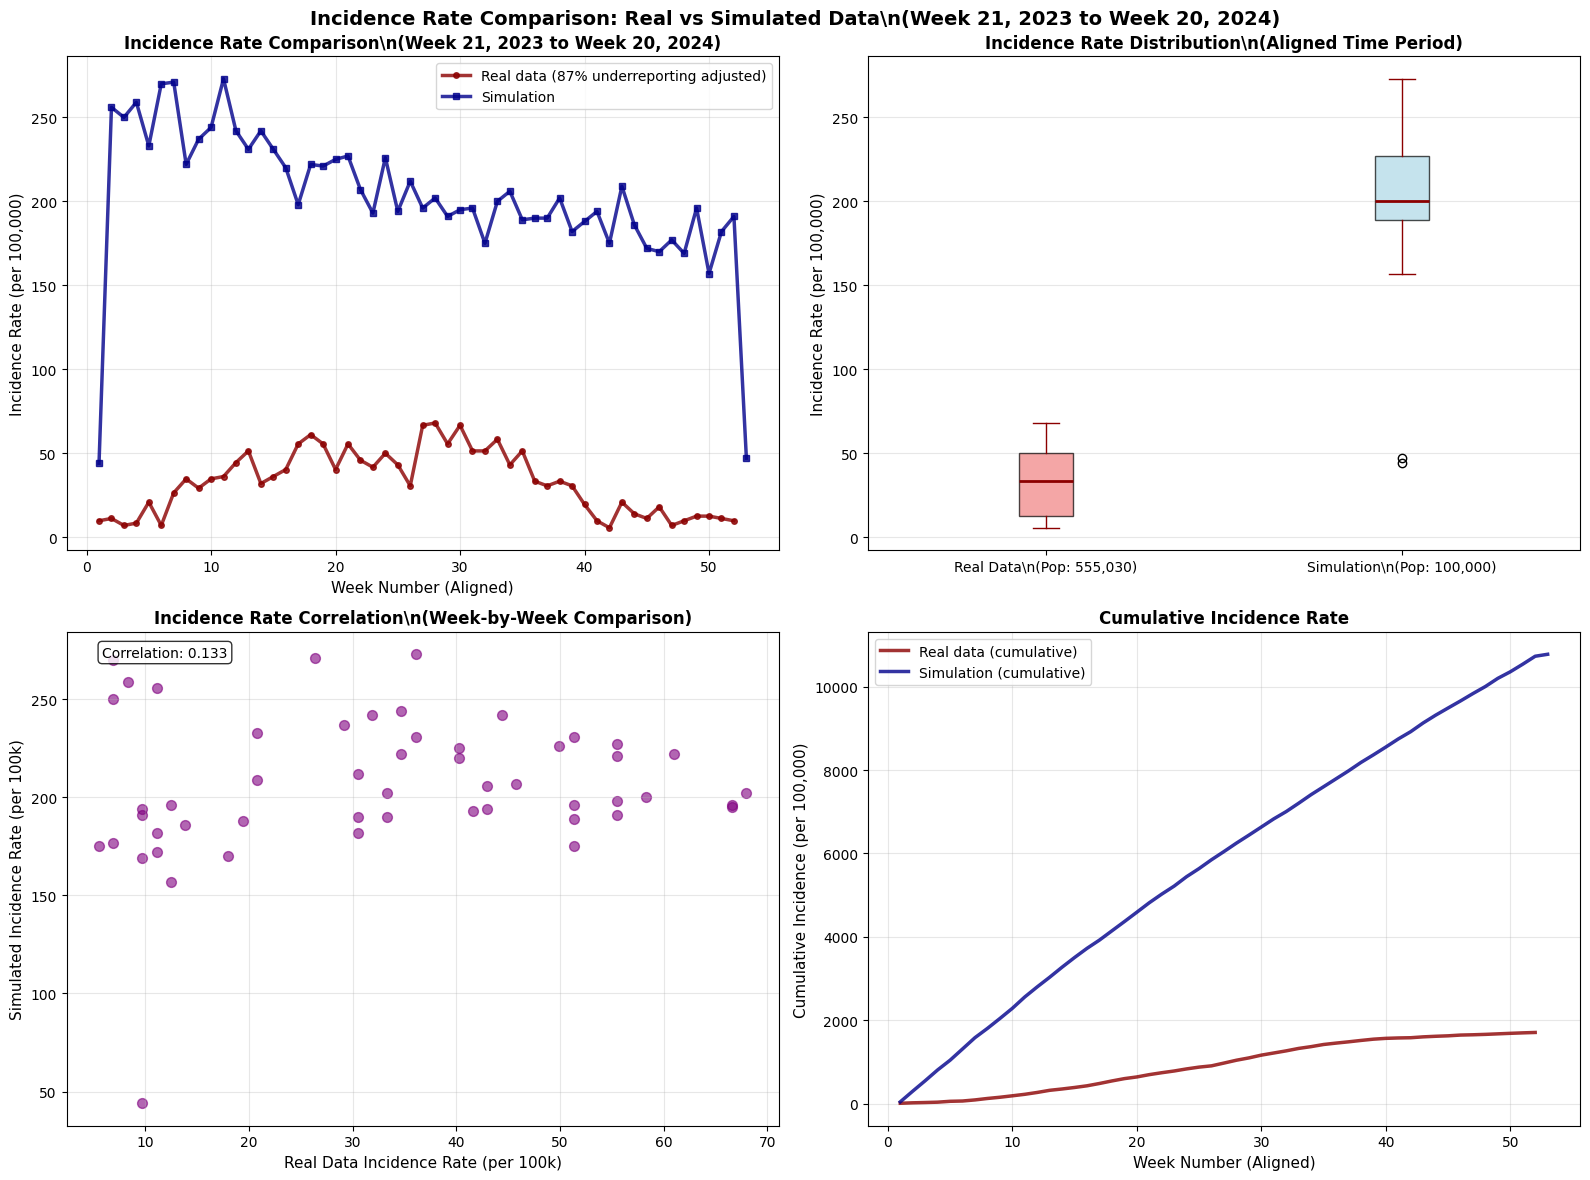

\n================================================================================
INCIDENCE RATE COMPARISON (per 100,000 population): REAL vs SIMULATED
\nREAL DATA (Santa Marta, Week 21 2023 to Week 20 2024):
  Population: 555,030
  Sample size: 52 weeks
  Mean incidence rate: 32.84 per 100k
  Median incidence rate: 33.30 per 100k
  Std Dev: 18.92
  Peak incidence: 67.98 per 100k (Week 48)
\nSIMULATED DATA (Agent-Based Model, Same time period):
  Population: 100,000
  Sample size: 53 weeks
  Mean incidence rate: 203.34 per 100k
  Median incidence rate: 200.00 per 100k
  Std Dev: 42.40
  Peak incidence: 273.00 per 100k (Week 11)
\nCOMPARISON RATIOS:
  Mean incidence ratio (Real/Sim): 0.16
  Peak incidence ratio (Real/Sim): 0.25
  → Simulation shows 6.2× higher mean incidence than real data
\n================================================================================
✓ Saved figure: incidence_rate_comparison_real_vs_simulated.png
✓ Saved data: incidence_rate_comparison.csv


In [30]:
# TIME-ALIGNED COMPARISON USING INCIDENCE RATES (per 100,000 population)
# This makes the comparison more meaningful regardless of population size

# Population constants
SANTA_MARTA_POP = 555030  # Santa Marta 2023 population
MODEL_POP = 100000  # Model population

# Calculate incidence rates for simulation
if 'weekly_cases' in locals() and not weekly_cases.empty:
    weekly_cases['incidence_rate_sim'] = (weekly_cases['new_cases_weekly'] / MODEL_POP) * 100000
    
    # Get real data incidence rates (already calculated)
    real_incidence = real_aligned['incidence_rate_adjusted'].dropna()
    sim_incidence = weekly_cases['incidence_rate_sim'].dropna()
    
    # Create comparison plots using incidence rates
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # --- TOP LEFT: Time series comparison (INCIDENCE RATE) ---
    ax1.plot(real_aligned['aligned_week'], real_aligned['incidence_rate_adjusted'], 
            linewidth=2.5, color='darkred', marker='o', markersize=4, 
            label='Real data (87% underreporting adjusted)', alpha=0.8)
    
    ax1.plot(weekly_cases['week'], weekly_cases['incidence_rate_sim'], 
            linewidth=2.5, color='darkblue', marker='s', markersize=4, 
            label='Simulation', alpha=0.8)
    
    ax1.set_title('Incidence Rate Comparison\\n(Week 21, 2023 to Week 20, 2024)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Week Number (Aligned)', fontsize=11)
    ax1.set_ylabel('Incidence Rate (per 100,000)', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # --- TOP RIGHT: Boxplot comparison (INCIDENCE RATE) ---
    box_plot = ax2.boxplot([real_incidence, sim_incidence], patch_artist=True, 
               tick_labels=[f'Real Data\\n(Pop: {SANTA_MARTA_POP:,})', f'Simulation\\n(Pop: {MODEL_POP:,})'],
               boxprops=dict(facecolor='lightcoral', alpha=0.7),
               medianprops=dict(color='darkred', linewidth=2),
               whiskerprops=dict(color='darkred'),
               capprops=dict(color='darkred'))
    
    # Color simulation box differently
    boxes = box_plot['boxes']
    if len(boxes) >= 2:
        boxes[1].set_facecolor('lightblue')
        boxes[1].set_alpha(0.7)
    
    ax2.set_title('Incidence Rate Distribution\\n(Aligned Time Period)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Incidence Rate (per 100,000)', fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # --- BOTTOM LEFT: Scatter plot correlation (INCIDENCE RATE) ---
    min_len = min(len(real_incidence), len(sim_incidence))
    ax3.scatter(real_incidence[:min_len], sim_incidence[:min_len], 
               alpha=0.6, s=50, color='purple')
    ax3.set_xlabel('Real Data Incidence Rate (per 100k)', fontsize=11)
    ax3.set_ylabel('Simulated Incidence Rate (per 100k)', fontsize=11)
    ax3.set_title('Incidence Rate Correlation\\n(Week-by-Week Comparison)', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    try:
        if min_len > 1:
            correlation = np.corrcoef(real_incidence[:min_len], sim_incidence[:min_len])[0,1]
            ax3.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                    transform=ax3.transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except Exception as e:
        ax3.text(0.05, 0.95, 'Correlation: N/A', 
                transform=ax3.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # --- BOTTOM RIGHT: Cumulative incidence (INCIDENCE RATE) ---
    real_cumulative_incidence = real_aligned['incidence_rate_adjusted'].cumsum()
    sim_cumulative_incidence = weekly_cases['incidence_rate_sim'].cumsum()
    
    ax4.plot(real_aligned['aligned_week'], real_cumulative_incidence, 
            linewidth=2.5, color='darkred', label='Real data (cumulative)', alpha=0.8)
    ax4.plot(weekly_cases['week'], sim_cumulative_incidence, 
            linewidth=2.5, color='darkblue', label='Simulation (cumulative)', alpha=0.8)
    
    ax4.set_title('Cumulative Incidence Rate', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Week Number (Aligned)', fontsize=11)
    ax4.set_ylabel('Cumulative Incidence (per 100,000)', fontsize=11)
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=10)
    
    plt.suptitle('Incidence Rate Comparison: Real vs Simulated Data\\n(Week 21, 2023 to Week 20, 2024)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('incidence_rate_comparison_real_vs_simulated.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed comparison
    print("\\n" + "=" * 80)
    print("INCIDENCE RATE COMPARISON (per 100,000 population): REAL vs SIMULATED")
    print("=" * 80)
    
    print(f"\\nREAL DATA (Santa Marta, Week 21 2023 to Week 20 2024):")
    print(f"  Population: {SANTA_MARTA_POP:,}")
    print(f"  Sample size: {len(real_incidence)} weeks")
    print(f"  Mean incidence rate: {real_incidence.mean():.2f} per 100k")
    print(f"  Median incidence rate: {real_incidence.median():.2f} per 100k")
    print(f"  Std Dev: {real_incidence.std():.2f}")
    print(f"  Peak incidence: {real_incidence.max():.2f} per 100k " + 
          f"(Week {int(real_aligned.loc[real_aligned['incidence_rate_adjusted'].idxmax(), 'week'])})")
    
    print(f"\\nSIMULATED DATA (Agent-Based Model, Same time period):")
    print(f"  Population: {MODEL_POP:,}")
    print(f"  Sample size: {len(sim_incidence)} weeks")
    print(f"  Mean incidence rate: {sim_incidence.mean():.2f} per 100k")
    print(f"  Median incidence rate: {sim_incidence.median():.2f} per 100k")
    print(f"  Std Dev: {sim_incidence.std():.2f}")
    print(f"  Peak incidence: {sim_incidence.max():.2f} per 100k " +
          f"(Week {int(weekly_cases.loc[weekly_cases['incidence_rate_sim'].idxmax(), 'week'])})")
    
    # Calculate relative differences
    mean_ratio = real_incidence.mean() / sim_incidence.mean()
    peak_ratio = real_incidence.max() / sim_incidence.max()
    
    print(f"\\nCOMPARISON RATIOS:")
    print(f"  Mean incidence ratio (Real/Sim): {mean_ratio:.2f}")
    print(f"  Peak incidence ratio (Real/Sim): {peak_ratio:.2f}")
    
    if mean_ratio > 1:
        print(f"  → Real data shows {mean_ratio:.1f}× higher mean incidence than simulation")
    else:
        print(f"  → Simulation shows {1/mean_ratio:.1f}× higher mean incidence than real data")
    
    print("\\n" + "=" * 80)
    print("✓ Saved figure: incidence_rate_comparison_real_vs_simulated.png")
    print("=" * 80)
    
    # Save comparison data
    try:
        incidence_comparison = pd.DataFrame({
            'aligned_week': real_aligned['aligned_week'],
            'real_week': real_aligned['week'],
            'real_year': real_aligned['year'],
            'real_incidence_rate': real_aligned['incidence_rate_adjusted'],
            'simulated_incidence_rate': sim_incidence[:len(real_aligned)].values
        })
        incidence_comparison.to_csv('incidence_rate_comparison.csv', index=False)
        print("✓ Saved data: incidence_rate_comparison.csv")
    except Exception as e:
        print(f"Error saving data: {e}")
else:
    print("weekly_cases not available - cannot compute incidence rates")


## Results

Total weeks: 53
Peak week: Week 11 with 273 cases
Mean weekly cases: 203.3
Total cases: 10777

Saved figures: sei_counts.png, new_cases.png, prevalence.png, incidence_rate.png, weekly_new_cases.png, stacked_props.png


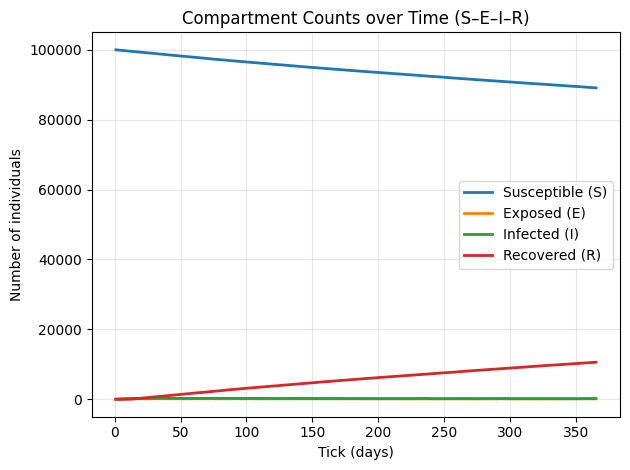

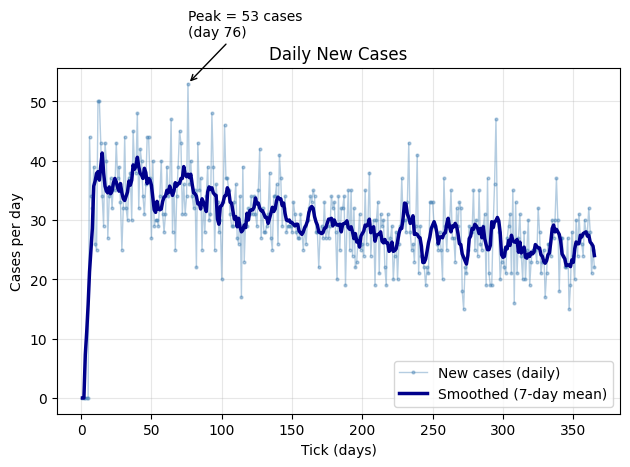

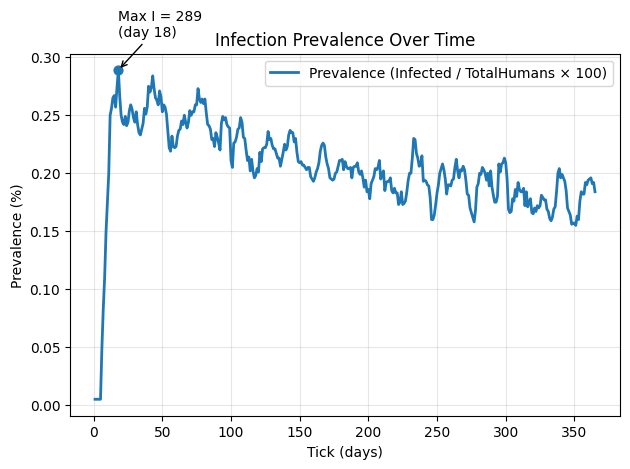

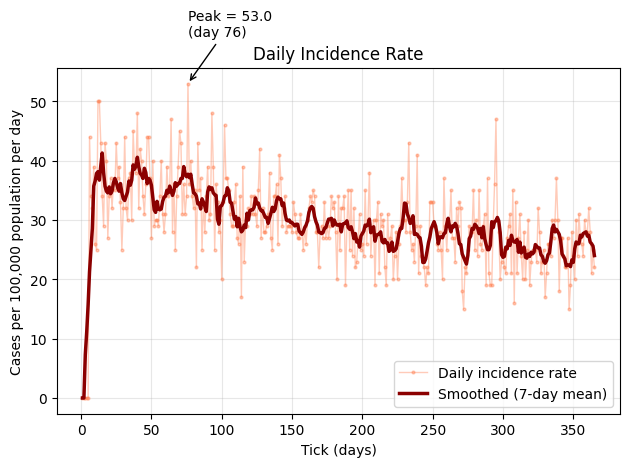

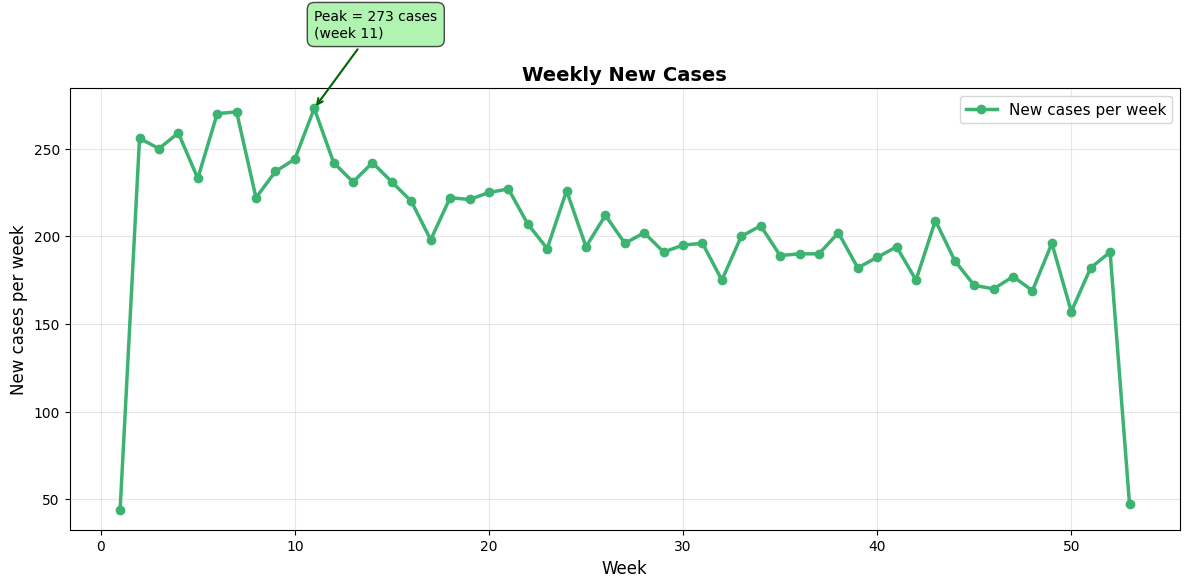

In [15]:
df = pd.read_csv("results_100k_cop.csv")

# Standardize column access (in case of stray spaces or mixed case)
df.columns = [c.strip() for c in df.columns]

# Basic derived metrics
df["Prevalence_%"] = 100.0 * df["Infected"] / df["TotalHumans"]

# A light smoothing for incidence (3-day centered window by default where possible)
# For very short series this reverts to available points without extrapolation.
if len(df) >= 7:
    df["NewCases_smooth"] = df["New Cases per day"].rolling(window=7, center=True, min_periods=1).mean()
else:
    df["NewCases_smooth"] = df["New Cases per day"].astype(float)

# Locate peaks for clear annotation
peak_I_idx = int(df["Infected"].idxmax())
peak_I_tick = int(df.loc[peak_I_idx, "tick"])
peak_I_val = int(df.loc[peak_I_idx, "Infected"])

peak_NC_idx = int(df["New Cases per day"].idxmax())
peak_NC_tick = int(df.loc[peak_NC_idx, "tick"])
peak_NC_val = int(df.loc[peak_NC_idx, "New Cases per day"])

# -----------------------------
# 2) Figure: S–E–I–R counts
# -----------------------------
plt.figure()
plt.plot(df["tick"], df["Susceptible"], label="Susceptible (S)", linewidth=2)
plt.plot(df["tick"], df["Exposed"],     label="Exposed (E)",     linewidth=2)
plt.plot(df["tick"], df["Infected"],    label="Infected (I)",    linewidth=2)
plt.plot(df["tick"], df["Recovered"],   label="Recovered (R)",   linewidth=2)
plt.title("Compartment Counts over Time (S–E–I–R)")
plt.xlabel("Tick (days)")
plt.ylabel("Number of individuals")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("sei_counts.png", dpi=300)

# -----------------------------
# 3) Figure: New cases per day
# -----------------------------
plt.figure()
# Raw daily new cases as line with markers
plt.plot(df["tick"], df["New Cases per day"], linewidth=1, alpha=0.4, 
         label="New cases (daily)", color="steelblue", marker='o', markersize=2)
# Smoothed overlay for trend visibility
plt.plot(df["tick"], df["NewCases_smooth"], linewidth=2.5, 
         label="Smoothed (7-day mean)", color="darkblue")
# Annotate the peak
plt.annotate(f"Peak = {peak_NC_val} cases\n(day {peak_NC_tick})",
             xy=(peak_NC_tick, peak_NC_val),
             xytext=(peak_NC_tick, peak_NC_val * 1.15 if peak_NC_val > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.title("Daily New Cases")
plt.xlabel("Tick (days)")
plt.ylabel("Cases per day")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("new_cases.png", dpi=300)

# -----------------------------
# 4) Figure: Infection prevalence
# -----------------------------
plt.figure()
plt.plot(df["tick"], df["Prevalence_%"], linewidth=2, label="Prevalence (Infected / TotalHumans × 100)")
plt.title("Infection Prevalence Over Time")
plt.xlabel("Tick (days)")
plt.ylabel("Prevalence (%)")
plt.grid(True, alpha=0.3)
# Mark and annotate the peak
plt.scatter([peak_I_tick], [100.0 * peak_I_val / df.loc[peak_I_idx, "TotalHumans"]], s=40)
plt.annotate(f"Max I = {peak_I_val}\n(day {peak_I_tick})",
             xy=(peak_I_tick, 100.0 * peak_I_val / df.loc[peak_I_idx, "TotalHumans"]),
             xytext=(peak_I_tick, max(df["Prevalence_%"]) * 1.1 if max(df["Prevalence_%"]) > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.legend()
plt.tight_layout()
plt.savefig("prevalence.png", dpi=300)

# -----------------------------
# 5) Figure: Incidence Rate (per 100,000 population)
# -----------------------------
# Calculate incidence rate: (new cases / total population) × 100,000
df["Incidence_Rate"] = (df["New Cases per day"] / df["TotalHumans"]) * 100000

# Smooth the incidence rate for better visualization
if len(df) >= 7:
    df["Incidence_Rate_smooth"] = df["Incidence_Rate"].rolling(window=7, center=True, min_periods=1).mean()
else:
    df["Incidence_Rate_smooth"] = df["Incidence_Rate"]

plt.figure()
# Raw incidence rate as line with markers
plt.plot(df["tick"], df["Incidence_Rate"], linewidth=1, alpha=0.4, 
         label="Daily incidence rate", color="coral", marker='o', markersize=2)
# Smoothed overlay
plt.plot(df["tick"], df["Incidence_Rate_smooth"], linewidth=2.5, 
         color='darkred', label="Smoothed (7-day mean)")

# Find and annotate peak
peak_IR_idx = int(df["Incidence_Rate"].idxmax())
peak_IR_tick = int(df.loc[peak_IR_idx, "tick"])
peak_IR_val = df.loc[peak_IR_idx, "Incidence_Rate"]

plt.annotate(f"Peak = {peak_IR_val:.1f}\n(day {peak_IR_tick})",
             xy=(peak_IR_tick, peak_IR_val),
             xytext=(peak_IR_tick, peak_IR_val * 1.15 if peak_IR_val > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))

plt.title("Daily Incidence Rate")
plt.xlabel("Tick (days)")
plt.ylabel("Cases per 100,000 population per day")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("incidence_rate.png", dpi=300)

# -----------------------------
# 6) Figure: Weekly New Cases
# -----------------------------
# Aggregate daily cases into weekly totals
df["week"] = (df["tick"] // 7) + 1  # Convert tick to week number (starting from week 1)
weekly_cases = df.groupby("week").agg({
    "New Cases per day": "sum",
    "tick": "max"  # Use the last tick of each week for x-axis
}).reset_index()
weekly_cases.rename(columns={"New Cases per day": "new_cases_weekly"}, inplace=True)

plt.figure(figsize=(12, 6))
# Plot weekly cases as line with markers
plt.plot(weekly_cases["week"], weekly_cases["new_cases_weekly"], 
         linewidth=2.5, color="mediumseagreen", marker='o', markersize=6, 
         label="New cases per week")

# Find and annotate peak week
peak_week_idx = weekly_cases["new_cases_weekly"].idxmax()
peak_week = weekly_cases.loc[peak_week_idx, "week"]
peak_week_val = weekly_cases.loc[peak_week_idx, "new_cases_weekly"]

plt.annotate(f"Peak = {int(peak_week_val)} cases\n(week {int(peak_week)})",
             xy=(peak_week, peak_week_val),
             xytext=(peak_week, peak_week_val * 1.15 if peak_week_val > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="darkgreen"),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

plt.title("Weekly New Cases", fontsize=14, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("New cases per week", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("weekly_new_cases.png", dpi=300)

print(f"Total weeks: {int(weekly_cases['week'].max())}")
print(f"Peak week: Week {int(peak_week)} with {int(peak_week_val)} cases")
print(f"Mean weekly cases: {weekly_cases['new_cases_weekly'].mean():.1f}")
print(f"Total cases: {int(weekly_cases['new_cases_weekly'].sum())}")

# -----------------------------
# 7) Figure: Stacked proportions
# -----------------------------
# Convert to proportions to visualize compos 8ition dynamics
total = df[["Susceptible", "Exposed", "Infected", "Recovered"]].sum(axis=1)
props = pd.DataFrame({
    "tick": df["tick"],
    "S": df["Susceptible"] / total,
    "E": df["Exposed"]     / total,
    "I": df["Infected"]    / total,
    "R": df["Recovered"]   / total
})


print("\nSaved figures: sei_counts.png, new_cases.png, prevalence.png, incidence_rate.png, weekly_new_cases.png, stacked_props.png")


Total weeks: 5
Peak week: Week 3 with 264 cases
Mean weekly cases: 176.4
Total cases: 882


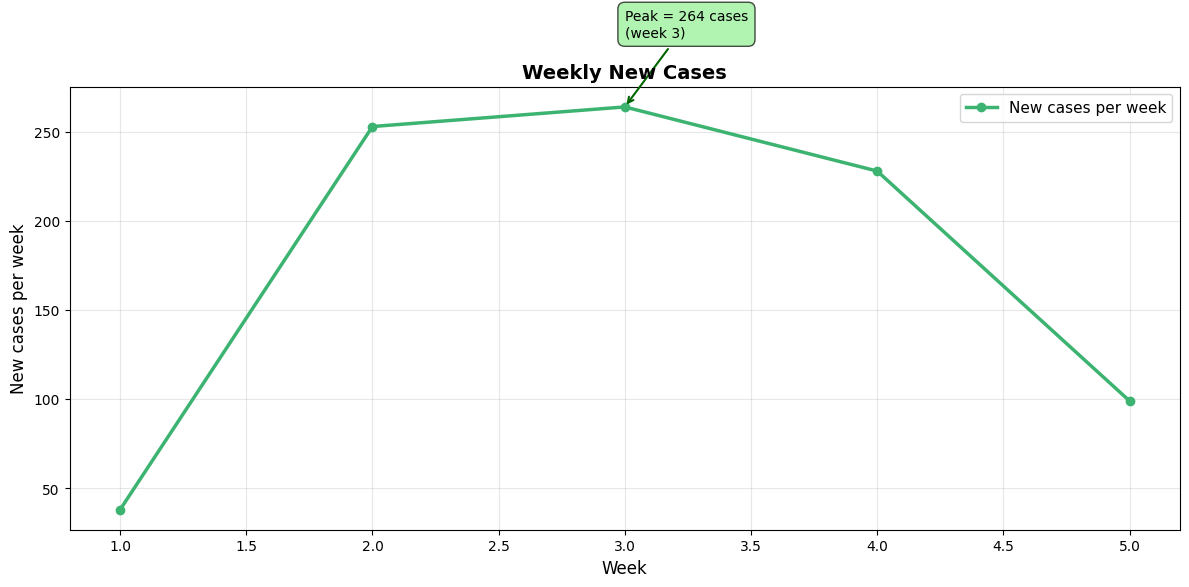

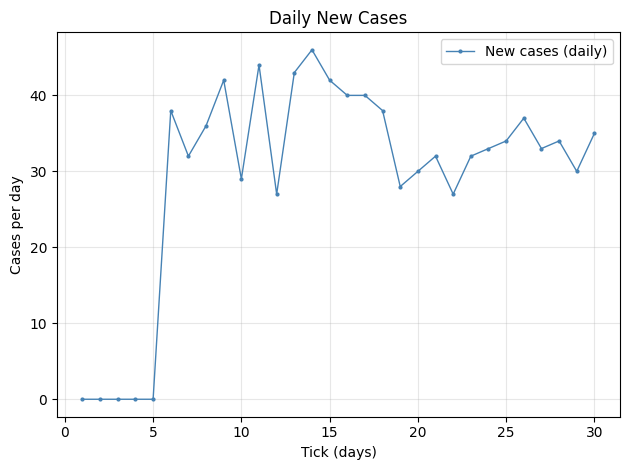

In [25]:
df_test = pd.read_csv("results_10k_30days.csv")

# Standardize column access (in case of stray spaces or mixed case)
df_test.columns = [c.strip() for c in df_test.columns]
# -----------------------------
# 6) Figure: Weekly New Cases
# -----------------------------
# Aggregate daily cases into weekly totals
df_test["week"] = (df_test["tick"] // 7) + 1  # Convert tick to week number (starting from week 1)
weekly_cases = df_test.groupby("week").agg({
    "New Cases per day": "sum",
    "tick": "max"  # Use the last tick of each week for x-axis
}).reset_index()
weekly_cases.rename(columns={"New Cases per day": "new_cases_weekly"}, inplace=True)

plt.figure(figsize=(12, 6))
# Plot weekly cases as line with markers
plt.plot(weekly_cases["week"], weekly_cases["new_cases_weekly"], 
         linewidth=2.5, color="mediumseagreen", marker='o', markersize=6, 
         label="New cases per week")

# Find and annotate peak week
peak_week_idx = weekly_cases["new_cases_weekly"].idxmax()
peak_week = weekly_cases.loc[peak_week_idx, "week"]
peak_week_val = weekly_cases.loc[peak_week_idx, "new_cases_weekly"]

plt.annotate(f"Peak = {int(peak_week_val)} cases\n(week {int(peak_week)})",
             xy=(peak_week, peak_week_val),
             xytext=(peak_week, peak_week_val * 1.15 if peak_week_val > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="darkgreen"),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

plt.title("Weekly New Cases", fontsize=14, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("New cases per week", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("weekly_new_cases.png", dpi=300)

print(f"Total weeks: {int(weekly_cases['week'].max())}")
print(f"Peak week: Week {int(peak_week)} with {int(peak_week_val)} cases")
print(f"Mean weekly cases: {weekly_cases['new_cases_weekly'].mean():.1f}")
print(f"Total cases: {int(weekly_cases['new_cases_weekly'].sum())}")

plt.figure()
# Raw daily new cases as line with markers
plt.plot(df_test["tick"], df_test["New Cases per day"], linewidth=1, alpha=1, 
         label="New cases (daily)", color="steelblue", marker='o', markersize=2)
plt.title("Daily New Cases")
plt.xlabel("Tick (days)")
plt.ylabel("Cases per day")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

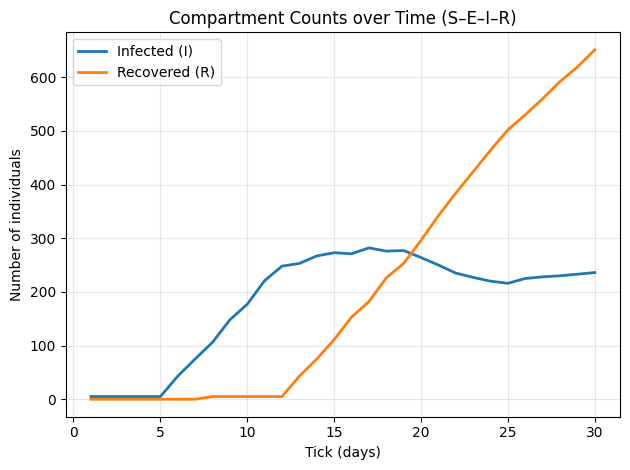

In [27]:
plt.figure()

plt.plot(df_test["tick"], df_test["Infected"],    label="Infected (I)",    linewidth=2)
plt.plot(df_test["tick"], df_test["Recovered"],   label="Recovered (R)",   linewidth=2)
plt.title("Compartment Counts over Time (S–E–I–R)")
plt.xlabel("Tick (days)")
plt.ylabel("Number of individuals")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("sei_counts.png", dpi=300)

## Resultados para los dos barrios

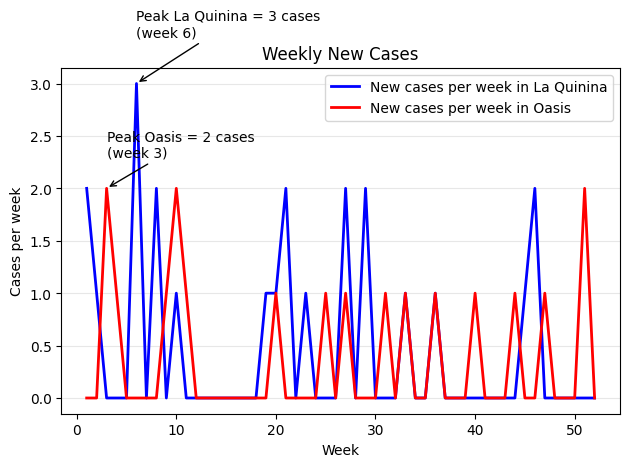

In [15]:
df_neighborhoods = pd.read_csv("weekly_neighborhood_cases.csv")


peak_NC_idx_oasis = int(df_neighborhoods["new_cases_oasis"].idxmax())
peak_NC_tick_oasis = int(df_neighborhoods.loc[peak_NC_idx_oasis, "week"])
peak_NC_val_oasis = int(df_neighborhoods.loc[peak_NC_idx_oasis, "new_cases_oasis"])

peak_NC_idx_quinina = int(df_neighborhoods["new_cases_laquinina"].idxmax())
peak_NC_tick_quinina = int(df_neighborhoods.loc[peak_NC_idx_quinina, "week"])
peak_NC_val_quinina = int(df_neighborhoods.loc[peak_NC_idx_quinina, "new_cases_laquinina"])

plt.figure()

# Smoothed overlay for trend visibility
plt.plot(df_neighborhoods["week"], df_neighborhoods["new_cases_laquinina"], linewidth=2, label="New cases per week in La Quinina", color="blue")
plt.plot(df_neighborhoods["week"], df_neighborhoods["new_cases_oasis"], linewidth=2, label="New cases per week in Oasis", color="red")
# Annotate the peak
plt.annotate(f"Peak Oasis = {peak_NC_val_oasis} cases\n(week {peak_NC_tick_oasis})",
             xy=(peak_NC_tick_oasis, peak_NC_val_oasis),
             xytext=(peak_NC_tick_oasis, peak_NC_val_oasis * 1.15 if peak_NC_val_oasis > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))
plt.annotate(f"Peak La Quinina = {peak_NC_val_quinina} cases\n(week {peak_NC_tick_quinina})",
             xy=(peak_NC_tick_quinina, peak_NC_val_quinina),
             xytext=(peak_NC_tick_quinina, peak_NC_val_quinina * 1.15 if peak_NC_val_quinina > 0 else 1.0),
             arrowprops=dict(arrowstyle="->", lw=1))

plt.title("Weekly New Cases")
plt.xlabel("Week")
plt.ylabel("Cases per week")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("new_cases_neighborhoods.png", dpi=300)





=== INCIDENCE RATE SUMMARY (per 1000 people per week) ===

Oasis:
  Mean:   0.66
  Median: 0.00
  Max:    3.81
  Total new cases: 18

La Quinina:
  Mean:   1.96
  Median: 0.00
  Max:    13.27
  Total new cases: 23


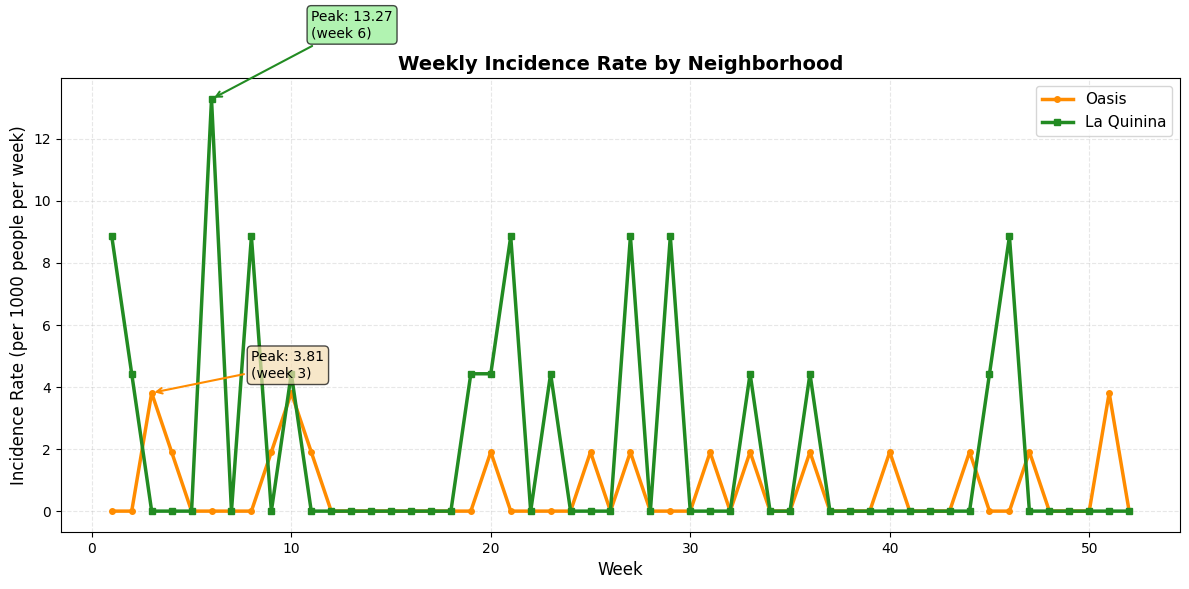

✓ Saved figure: incidence_rate_line.png


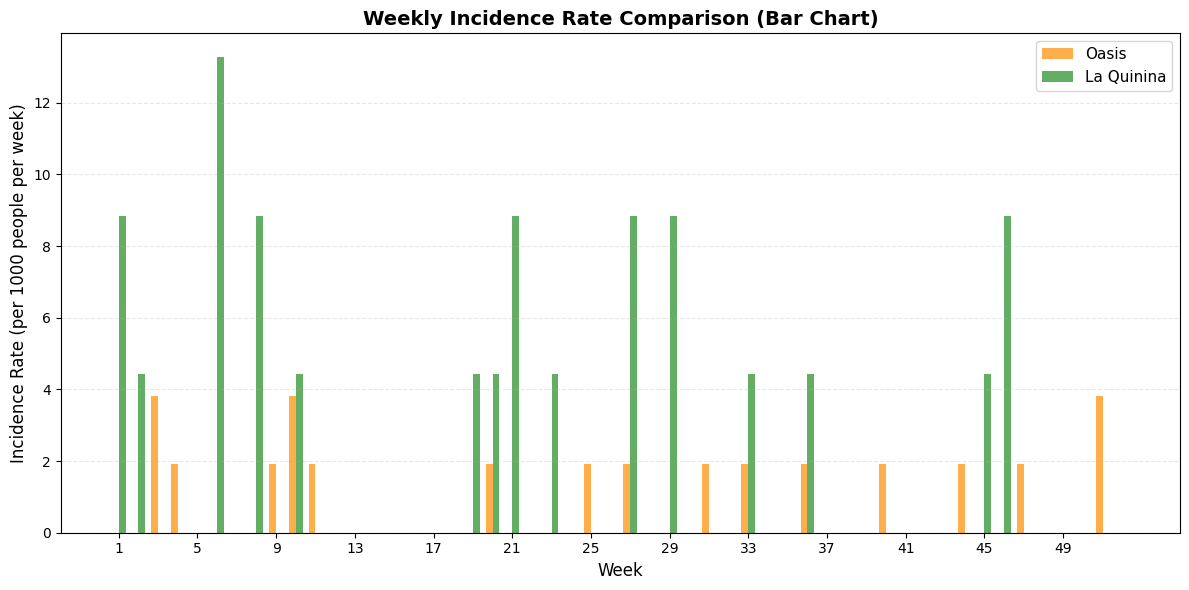

✓ Saved figure: incidence_rate_bar.png


In [16]:
# Calculate Incidence Rates for both neighborhoods
# Incidence Rate = (New Cases / Population at Risk) × 1000 (per 1000 people per week)
df_neighborhoods = pd.read_csv("weekly_neighborhood_cases.csv")
df_neighborhoods["incidence_rate_oasis"] = (
    df_neighborhoods["new_cases_oasis"] / df_neighborhoods["total_humans_oasis"]
) * 1000

df_neighborhoods["incidence_rate_laquinina"] = (
    df_neighborhoods["new_cases_laquinina"] / df_neighborhoods["total_humans_laquinina"]
) * 1000

# Summary statistics
print("=== INCIDENCE RATE SUMMARY (per 1000 people per week) ===\n")
print(f"Oasis:")
print(f"  Mean:   {df_neighborhoods['incidence_rate_oasis'].mean():.2f}")
print(f"  Median: {df_neighborhoods['incidence_rate_oasis'].median():.2f}")
print(f"  Max:    {df_neighborhoods['incidence_rate_oasis'].max():.2f}")
print(f"  Total new cases: {df_neighborhoods['new_cases_oasis'].sum()}")

print(f"\nLa Quinina:")
print(f"  Mean:   {df_neighborhoods['incidence_rate_laquinina'].mean():.2f}")
print(f"  Median: {df_neighborhoods['incidence_rate_laquinina'].median():.2f}")
print(f"  Max:    {df_neighborhoods['incidence_rate_laquinina'].max():.2f}")
print(f"  Total new cases: {df_neighborhoods['new_cases_laquinina'].sum()}")

# Find peaks
peak_IR_oasis_idx = df_neighborhoods["incidence_rate_oasis"].idxmax()
peak_IR_oasis_week = df_neighborhoods.loc[peak_IR_oasis_idx, "week"]
peak_IR_oasis_val = df_neighborhoods.loc[peak_IR_oasis_idx, "incidence_rate_oasis"]

peak_IR_quinina_idx = df_neighborhoods["incidence_rate_laquinina"].idxmax()
peak_IR_quinina_week = df_neighborhoods.loc[peak_IR_quinina_idx, "week"]
peak_IR_quinina_val = df_neighborhoods.loc[peak_IR_quinina_idx, "incidence_rate_laquinina"]

# PLOT 1: Line plot with both neighborhoods
plt.figure(figsize=(12, 6))

plt.plot(df_neighborhoods["week"], df_neighborhoods["incidence_rate_oasis"], 
         linewidth=2.5, label="Oasis", color="darkorange", marker='o', markersize=4)
plt.plot(df_neighborhoods["week"], df_neighborhoods["incidence_rate_laquinina"], 
         linewidth=2.5, label="La Quinina", color="forestgreen", marker='s', markersize=4)

# Annotate peaks
plt.annotate(f"Peak: {peak_IR_oasis_val:.2f}\n(week {int(peak_IR_oasis_week)})",
             xy=(peak_IR_oasis_week, peak_IR_oasis_val),
             xytext=(peak_IR_oasis_week + 5, peak_IR_oasis_val + 0.5),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="darkorange"),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.7))

plt.annotate(f"Peak: {peak_IR_quinina_val:.2f}\n(week {int(peak_IR_quinina_week)})",
             xy=(peak_IR_quinina_week, peak_IR_quinina_val),
             xytext=(peak_IR_quinina_week + 5, peak_IR_quinina_val + 2),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="forestgreen"),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

plt.title("Weekly Incidence Rate by Neighborhood", fontsize=14, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Incidence Rate (per 1000 people per week)", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig("incidence_rate_line.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved figure: incidence_rate_line.png")

# PLOT 2: Bar chart comparison
plt.figure(figsize=(12, 6))

x = np.arange(len(df_neighborhoods))
width = 0.35

bars1 = plt.bar(x - width/2, df_neighborhoods["incidence_rate_oasis"], 
                width, label="Oasis", color="darkorange", alpha=0.7)
bars2 = plt.bar(x + width/2, df_neighborhoods["incidence_rate_laquinina"], 
                width, label="La Quinina", color="forestgreen", alpha=0.7)

plt.title("Weekly Incidence Rate Comparison (Bar Chart)", fontsize=14, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Incidence Rate (per 1000 people per week)", fontsize=12)
plt.xticks(x[::4], df_neighborhoods["week"][::4].astype(int))  # Show every 4th week
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("incidence_rate_bar.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved figure: incidence_rate_bar.png")


## Understanding Incidence Rate vs. Prevalence Rate

### **Incidence Rate**
- **Definition:** Measures the rate of **NEW cases** occurring in a population over a specific time period
- **Formula:** `(Number of new cases / Population at risk) × multiplier (e.g., 1000)`
- **Unit:** Cases per 1000 people per week (or per day, month, year)
- **Question answered:** "How fast is the disease spreading?"
- **Use case:** Tracking disease transmission dynamics, identifying outbreaks, evaluating intervention effectiveness
- **Example:** If 5 new dengue cases occur in a neighborhood of 500 people in one week:
  - Incidence rate = (5 / 500) × 1000 = **10 cases per 1000 people per week**

### **Prevalence Rate**
- **Definition:** Measures the **TOTAL proportion** of cases that exist in a population at a specific point in time
- **Formula:** `(Number of existing cases / Total population) × 100`
- **Unit:** Percentage (%)
- **Question answered:** "How much disease burden exists right now?"
- **Use case:** Assessing disease burden, healthcare resource planning
- **Example:** If 50 people currently have dengue in a neighborhood of 500 people:
  - Prevalence = (50 / 500) × 100 = **10% prevalence**

### **Key Differences**

| Aspect | Incidence Rate | Prevalence Rate |
|--------|----------------|-----------------|
| **What it counts** | New cases only | All existing cases |
| **Time dimension** | Rate over period (dynamic) | Snapshot in time (static) |
| **Disease stage** | New infections | Current infections |
| **Best for** | Outbreak detection, transmission tracking | Disease burden assessment |
| **Sensitive to** | Changes in transmission | Disease duration & transmission |

### **For Dengue Surveillance:**
**Incidence rate is more informative** because:
1. Shows real-time transmission dynamics
2. Detects outbreaks early (rapid increase in incidence)
3. Evaluates intervention impact (decrease in incidence)
4. Accounts for population differences between neighborhoods

In our simulation, we track **weekly incidence rates** for Oasis and La Quinina neighborhoods to compare dengue transmission patterns between areas with different population sizes.


## Plot real data from SIVIGILA

In [ ]:
# Export 52-week aligned incidence CSV for calibration (full year)
# Produces columns: week, week_continuous, incidence_rate_adjusted

if 'real_aligned' in locals() and not real_aligned.empty:
    # Ensure aligned_week exists and is 1..N
    if 'aligned_week' not in real_aligned.columns:
        real_aligned = real_aligned.sort_values(['year', 'week']).copy()
        real_aligned['aligned_week'] = range(1, len(real_aligned) + 1)

    # Target exactly 52 weeks (one year)
    W = 52
    idx = pd.Index(range(1, W + 1), name='aligned_week')
    df = real_aligned.set_index('aligned_week')

    # Prefer precomputed incidence_rate_adjusted; compute if missing
    if 'incidence_rate_adjusted' not in df.columns:
        # Requires SANTA_MARTA_POP_2023 and adjusted_cases defined earlier
        df['incidence_rate_adjusted'] = (df['adjusted_cases'] / SANTA_MARTA_POP_2023) * 100000

    out = df.reindex(idx)[['incidence_rate_adjusted']].copy()
    out['week'] = out.index.astype(int)
    out['week_continuous'] = out.index.astype(int)
    out = out[['week', 'week_continuous', 'incidence_rate_adjusted']].reset_index(drop=True)

    # Fill any missing weeks by interpolation (then edge fill)
    if out['incidence_rate_adjusted'].isna().any():
        out['incidence_rate_adjusted'] = (
            out['incidence_rate_adjusted']
            .interpolate(limit_direction='both')
        )

    out.to_csv('incidence_rates_santa_marta.csv', index=False)
    print(f"\u2713 Wrote 52-week calibration CSV: incidence_rates_santa_marta.csv (rows={len(out)})")
else:
    print('real_aligned not available; run the alignment cell first.')
